# Hydrocarbon phase evolution: NeqSim PVT to OPM Flow

Companion to [NeqSim issue #4198](https://github.com/equinor/neqsim/issues/4198).

**Question:** how do pressure, temperature, and gas removal change hydrocarbon phase state,
and how can a compositional PVT study inform a gridded reservoir forecast and surface process?

This synthetic, executable study adds saturation-pressure, constant-mass expansion (CME),
and constant-volume depletion (CVD) experiments to the existing NeqSim–OPM coupling example.
It then runs an actual 300-cell OPM Flow black-oil case and converts production back into
NeqSim streams for separation and compression.

The paper cited in #4198 motivates the question; its fluid assays, geological history, and
measurements are not supplied by the issue. These results are **not a reproduction or validation
of that paper**, nor a model of the Mo-Yong area. Geological migration and molecular fractionation
require additional transport, charge-history, and compositional modeling.

Run all cells in a fresh Linux Google Colab CPU runtime. Initial installation and source build
can take several minutes. No API key or commercial simulator is required.

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/codex/issue-4198-phase-evolution-demo/notebooks/reservoir/hydrocarbon_phase_evolution_neqsim_opm.ipynb)


## Learning outcomes and acceptance criteria

After completing the notebook, you should be able to:

1. characterize TBP cuts and a plus fraction in NeqSim;
2. reduce a compositional EOS fluid to black-oil PVT tables;
3. assemble and run a gridded OPM Flow model from Python;
4. read Flow summary vectors without copying values by hand;
5. reconstruct a characterized NeqSim well stream from black-oil surface components;
6. connect reservoir output to a composable NeqSim process flowsheet; and
7. verify PVT monotonicity, deck parsing, convergence, material balance, and physical trends.

Completion requires every executable validation check near the end to pass.

## Coupling architecture

| Stage | Representation | Main quantities |
|---|---|---|
| PVT laboratory model | NeqSim SRK compositional fluid | component identities, C20+, EOS |
| Reservoir handoff | live-oil black-oil tables | $R_s$, $B_o$, $B_g$, viscosities, water PVT |
| Spatial forecast | OPM Flow | pressure, oil, gas, water, GOR, well BHP |
| Surface-component handoff | stock-tank oil + surface gas + water | Flow `WOPR`, `WGPR`, `WWPR` |
| Facility model | NeqSim characterized material stream | phases, composition, mass, power, heat |

Black-oil simulation conserves two hydrocarbon surface components rather than every molecular
component. The reverse conversion is therefore a model reconstruction, not recovery of
information that the black-oil model discarded. Its assumptions are stated explicitly below.

## Basis, units, provenance, and limits

- Pressures are absolute and use bara.
- Reservoir and PVT temperature is 97.5°C.
- Standard conditions are 15°C and 1.01325 bara.
- NeqSim uses SRK, classic mixing, volume correction, Pedersen characterization, and 12
  pseudo-components for C20+.
- OPM Flow uses a 10 × 10 × 3 Cartesian sector with heterogeneous layers, one producer, one
  water injector, solution gas, Corey-style relative-permeability tables, and 36 monthly steps.
- The wells belong to an explicit `WELLS` group below `FIELD`. This is accepted by current Flow
  and avoids a well-group lookup defect in the Flow 2021.10 package available on older Colab
  Ubuntu runtimes.
- Geometry and schedule are synthetic. The topology is inspired by the public SPE1 teaching
  pattern, but the grid, fluid, rates, units, and results are created here.
- Water properties use NeqSim's SRK-CPA Statoil model; no salinity is included.

Replace the fluid, regression data, rock functions, grid, well controls, and operating constraints
before asset use.

In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import platform
import re
import shutil
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.23.0",
    "opm": "2026.4",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


packages_need_install = any(
    installed_version(package_name) != required_version
    for package_name, required_version in REQUIRED_PACKAGES.items()
)
if packages_need_install:
    package_specs = [
        f"{package_name}=={required_version}"
        for package_name, required_version in REQUIRED_PACKAGES.items()
    ]
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *package_specs,
        ],
        check=True,
        timeout=600,
    )

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


FLOW_RUN_ENV = os.environ.copy()
FLOW_RUN_ENV["OMP_NUM_THREADS"] = "1"
if os.environ.get("OPM_FLOW_PYTHONHOME"):
    FLOW_RUN_ENV["PYTHONHOME"] = os.environ["OPM_FLOW_PYTHONHOME"]
FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE")
if FLOW_EXECUTABLE is None:
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    os_release = Path("/etc/os-release").read_text(encoding="utf-8")
    if "Ubuntu" not in os_release:
        raise RuntimeError(
            "The OPM binary installation cell requires an Ubuntu Colab runtime."
        )

    setup_commands = [
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "software-properties-common",
        ],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "libopm-simulators-bin",
        ],
    ]
    for setup_command in setup_commands:
        completed_setup = subprocess.run(
            setup_command,
            capture_output=True,
            text=True,
            timeout=900,
        )
        if completed_setup.returncode != 0:
            raise RuntimeError(
                "OPM Flow installation failed:\n"
                + completed_setup.stderr[-4000:]
            )
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    raise RuntimeError("OPM Flow executable was not found after installation.")

flow_version_run = subprocess.run(
    [FLOW_EXECUTABLE, "--version"],
    capture_output=True,
    env=FLOW_RUN_ENV,
    check=True,
    text=True,
    timeout=60,
)
flow_version_text = flow_version_run.stdout + flow_version_run.stderr
flow_version_match = re.search(r"flow\s+(\d{4}\.\d{2})", flow_version_text)
if flow_version_match is None:
    raise RuntimeError("Could not identify the installed OPM Flow version.")

runtime_table = pd.DataFrame(
    {
        "runtime": ["NeqSim", "OPM Python", "OPM Flow", "Python"],
        "version": [
            installed_version("neqsim"),
            installed_version("opm"),
            flow_version_match.group(1),
            platform.python_version(),
        ],
    }
)
display(runtime_table)

,runtime,version
0,NeqSim,3.23.0
1,OPM Python,2026.4
2,OPM Flow,2026.04
3,Python,3.12.14


In [2]:
# Pin the Java source, independently of the Python wrapper version.
import hashlib
import jpype

NEQSIM_SOURCE_REF = "4a0c9b93218cd77c3137ee53cffcd83050d8dfca"
NEQSIM_SOURCE_ROOT = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim_source"))
if not NEQSIM_SOURCE_ROOT.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/equinor/neqsim.git", str(NEQSIM_SOURCE_ROOT)],
        check=True,
        capture_output=True,
    )
    subprocess.run(
        ["git", "checkout", NEQSIM_SOURCE_REF],
        cwd=NEQSIM_SOURCE_ROOT,
        check=True,
        capture_output=True,
    )
source_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=NEQSIM_SOURCE_ROOT, text=True
).strip()
assert source_commit == NEQSIM_SOURCE_REF, "Wrong NeqSim source revision"
source_jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
if source_jar_override:
    source_jar = Path(source_jar_override).resolve()
else:
    subprocess.run(
        ["bash", "mvnw", "-q", "-DskipTests", "package"],
        cwd=NEQSIM_SOURCE_ROOT,
        check=True,
        timeout=1200,
    )
    source_jar = (NEQSIM_SOURCE_ROOT / "target/neqsim-3.23.0.jar").resolve()
assert source_jar.is_file()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
assert not jpype.isJVMStarted(), "Restart the runtime before Run all"
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xmx2g", convertStrings=False)
loaded_class = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
loaded_location = str(loaded_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert str(source_jar) in loaded_location
print("NeqSim source commit:", source_commit)
print("Source JAR SHA256:", hashlib.sha256(source_jar.read_bytes()).hexdigest())
print("Loaded class from verified source JAR:", source_jar.name)


NeqSim source commit: 4a0c9b93218cd77c3137ee53cffcd83050d8dfca
Source JAR SHA256: 77f98ddec383f36373402cc4bcadd7d4a73f10d93ce96e18bfde7af28eca5219
Loaded class from verified source JAR: neqsim-3.23.0.jar


## Black-oil quantities generated from the compositional model

For a differential-liberation path, NeqSim supplies the oil formation-volume factor

$$B_o(P) = \frac{V_o(P,T_R)}{V_{o,\mathrm{sc}}},$$

the solution gas-oil ratio

$$R_s(P) = \frac{V_{g,\mathrm{sc}}^{\mathrm{dissolved}}}
{V_{o,\mathrm{sc}}},$$

and the dry-gas formation-volume factor

$$B_g(P) = \frac{V_g(P,T_R)}{V_{g,\mathrm{sc}}}.$$

$T_R$ is reservoir temperature, $P$ is absolute pressure, and the standard volumes use the
stated standard conditions. `rm³/Sm³` denotes reservoir cubic metres per standard cubic metre.

In [3]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
from jpype import JClass
from neqsim import jneqsim
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    cooler,
    mixer,
    runProcess,
    separator,
    separator3phase,
    stream,
    valve,
)
from neqsim.thermo import TPflash
from opm.io import Parser
from opm.io.ecl import EclFile, EGrid, ERst, ESmry


plt.style.use("seaborn-v0_8-whitegrid")

RESERVOIR_TEMPERATURE_C = 97.5
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
INITIAL_RESERVOIR_PRESSURE_BARA = 260.0
PRODUCER_BHP_LIMIT_BARA = 80.0
SECONDS_PER_DAY = 86400.0

DLE_PRESSURES_BARA = np.array(
    [300.0, 250.0, 220.0, 200.0, 180.0, 150.0, 100.0, 50.0, 1.01325]
)
GAS_PVT_PRESSURES_BARA = np.array(
    [
        1.01325,
        25.0,
        50.0,
        75.0,
        100.0,
        125.0,
        150.0,
        175.0,
        200.0,
        225.0,
        250.0,
        275.0,
        300.0,
    ]
)

OUTPUT_DIRECTORY = Path("phase_evolution_opm_outputs")
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
OUTPUT_DIRECTORY.mkdir()

model_basis = pd.DataFrame(
    {
        "quantity": [
            "reservoir temperature",
            "initial reservoir pressure",
            "standard temperature",
            "standard pressure",
            "grid cells",
            "forecast length",
        ],
        "value": [97.5, 260.0, 15.0, 1.01325, 300, 36],
        "unit": ["°C", "bara", "°C", "bara", "count", "months"],
    }
)
display(model_basis)

,quantity,value,unit
0,reservoir temperature,97.50000,°C
1,initial reservoir pressure,260.00000,bara
2,standard temperature,15.00000,°C
3,standard pressure,1.01325,bara
4,grid cells,300.00000,count
5,forecast length,36.00000,months


## 1. Characterize the reservoir fluid in NeqSim

The synthetic bottom-hole sample contains named light components, C7–C19 TBP cuts, and a C20+
fraction. The plus fraction is characterized before any PVT experiment is run. This preserves a
compositional reference model with explicit pseudo-component identities for the later reverse
conversion.

In [4]:
LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]

TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]

PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)


def build_reservoir_fluid():
    fluid_model = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        INITIAL_RESERVOIR_PRESSURE_BARA,
    )

    for component_name, amount_mol_percent in LIGHT_COMPONENTS:
        fluid_model.addComponent(component_name, amount_mol_percent)

    for cut_name, amount, molar_mass, relative_density in TBP_CUTS:
        fluid_model.addTBPfraction(
            cut_name,
            amount,
            molar_mass,
            relative_density,
        )

    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    fluid_model.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )

    characterization = fluid_model.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()

    fluid_model.setMixingRule("classic")
    fluid_model.useVolumeCorrection(True)
    fluid_model.init(0)
    fluid_model.init(1)
    return fluid_model


reservoir_fluid = build_reservoir_fluid()

In [5]:
characterized_rows = []
for component_index in range(reservoir_fluid.getNumberOfComponents()):
    component = reservoir_fluid.getComponent(component_index)
    characterized_rows.append(
        {
            "component": str(component.getComponentName()),
            "mole_fraction": float(component.getz()),
            "molar_mass_g_mol": 1000.0 * float(component.getMolarMass()),
        }
    )

characterized_composition = pd.DataFrame(characterized_rows)
composition_sum = characterized_composition["mole_fraction"].sum()

initial_state = reservoir_fluid.clone()
initial_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
initial_state.setPressure(INITIAL_RESERVOIR_PRESSURE_BARA, "bara")
TPflash(initial_state)
initial_state.initPhysicalProperties()

SaturationPressure = jneqsim.pvtsimulation.simulation.SaturationPressure
saturation_calculation = SaturationPressure(reservoir_fluid.clone())
saturation_calculation.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_calculation.run()
bubble_pressure_reference_bara = (
    saturation_calculation.getSaturationPressure()
)

fluid_audit = pd.DataFrame(
    {
        "quantity": [
            "input assay closure",
            "characterized components",
            "characterized composition sum",
            "initial phase count",
            "bubble pressure",
        ],
        "value": [
            sum(amount for _, amount in LIGHT_COMPONENTS)
            + sum(row[1] for row in TBP_CUTS)
            + PLUS_FRACTION[1],
            reservoir_fluid.getNumberOfComponents(),
            composition_sum,
            initial_state.getNumberOfPhases(),
            bubble_pressure_reference_bara,
        ],
        "unit": ["mol%", "count", "mol/mol", "count", "bara"],
    }
)
display(fluid_audit)
display(characterized_composition)

,quantity,value,unit
0,input assay closure,100.000000,mol%
1,characterized components,22.000000,count
2,characterized composition sum,1.000000,mol/mol
3,initial phase count,1.000000,count
4,bubble pressure,193.240934,bara


,component,mole_fraction,molar_mass_g_mol
0,nitrogen,0.003900,28.013500
1,CO2,0.003000,44.010000
2,methane,0.402000,16.043000
3,ethane,0.076100,30.070000
4,propane,0.079500,44.097000
5,i-butane,0.011900,58.123000
6,n-butane,0.040800,58.123000
7,i-pentane,0.013900,72.151000
8,n-pentane,0.021500,72.150000
9,n-hexane,0.027900,86.177000


## A. Phase evolution and laboratory paths

CME keeps every molecule in a closed cell. CVD removes equilibrium gas to restore the
saturation cell volume after each pressure reduction. Differential liberation removes liberated
gas between stages. These paths have different composition histories and are not interchangeable.

We use the same characterized oil for CME and CVD to isolate the effect of the experimental
path. CVD is more commonly applied to gas-condensate fluids; this oil example is a controlled
comparison, not a representative condensate assay.

At each temperature, `SaturationPressure` finds a phase boundary. We independently flash just
above and below it to reject a search-limit sentinel. Temperatures are synthetic sensitivity
cases, not a reconstructed burial history. All pressures are absolute.


In [6]:
saturation_rows = []
for temperature_c in [70.0, 97.5, 130.0, 160.0]:
    sample = reservoir_fluid.clone()
    sample.setTemperature(temperature_c, "C")
    experiment = jneqsim.pvtsimulation.simulation.SaturationPressure(sample)
    experiment.run()
    saturation_bara = float(experiment.getSaturationPressure())
    phase_counts = []
    for multiplier in [0.99, 1.01]:
        check_state = reservoir_fluid.clone()
        check_state.setTemperature(temperature_c, "C")
        check_state.setPressure(saturation_bara * multiplier, "bara")
        TPflash(check_state)
        phase_counts.append(check_state.getNumberOfPhases())
    assert 1.0 < saturation_bara < 999.0
    assert phase_counts == [2, 1], phase_counts
    saturation_rows.append({
        "temperature_C": temperature_c,
        "saturation_pressure_bara": saturation_bara,
        "phases_below": phase_counts[0],
        "phases_above": phase_counts[1],
    })
saturation_results = pd.DataFrame(saturation_rows)
display(saturation_results)

lab_pressures = np.array([300.0, 250.0, 200.0, 150.0, 100.0, 50.0])
cme = jneqsim.pvtsimulation.simulation.ConstantMassExpansion(reservoir_fluid.clone())
cme.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
cme.setPressures(lab_pressures.tolist())
cme.runCalc()
cvd = jneqsim.pvtsimulation.simulation.ConstantVolumeDepletion(reservoir_fluid.clone())
cvd.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
cvd.setPressures(lab_pressures.tolist())
cvd.runCalc()
lab_results = pd.DataFrame({
    "pressure_bara": lab_pressures,
    "CME_relative_volume": np.asarray(cme.getRelativeVolume(), dtype=float),
    "CVD_removed_mol_percent": np.asarray(cvd.getCummulativeMolePercDepleted(), dtype=float),
})
assert np.isfinite(lab_results.to_numpy()).all()
assert (lab_results["CME_relative_volume"] > 0).all()
assert np.all(np.diff(lab_results["CME_relative_volume"]) > 0)
assert np.all(np.diff(lab_results["CVD_removed_mol_percent"]) >= -1e-8)
assert lab_results["CVD_removed_mol_percent"].between(0, 100).all()
assert abs(cme.getThermoSystem().getTotalNumberOfMoles()
           - reservoir_fluid.getTotalNumberOfMoles()) < 1e-9
removed_fraction = lab_results["CVD_removed_mol_percent"].iloc[-1] / 100.0
initial_moles = reservoir_fluid.getTotalNumberOfMoles()
remaining_moles = cvd.getThermoSystem().getTotalNumberOfMoles()
assert abs(remaining_moles / initial_moles + removed_fraction - 1.0) < 1e-8
display(lab_results)
print("CME mole conservation and CVD withdrawal accounting passed.")


CME mole conservation and CVD withdrawal accounting passed.


,temperature_C,saturation_pressure_bara,phases_below,phases_above
0,70.0,176.512657,2,1
1,97.5,193.240934,2,1
2,130.0,208.214460,2,1
3,160.0,218.024755,2,1


,pressure_bara,CME_relative_volume,CVD_removed_mol_percent
0,300.0,0.969145,0.000000
1,250.0,0.982223,0.000000
2,200.0,0.997683,0.000000
3,150.0,1.118150,9.593681
4,100.0,1.435458,23.005184
5,50.0,2.566058,39.028104


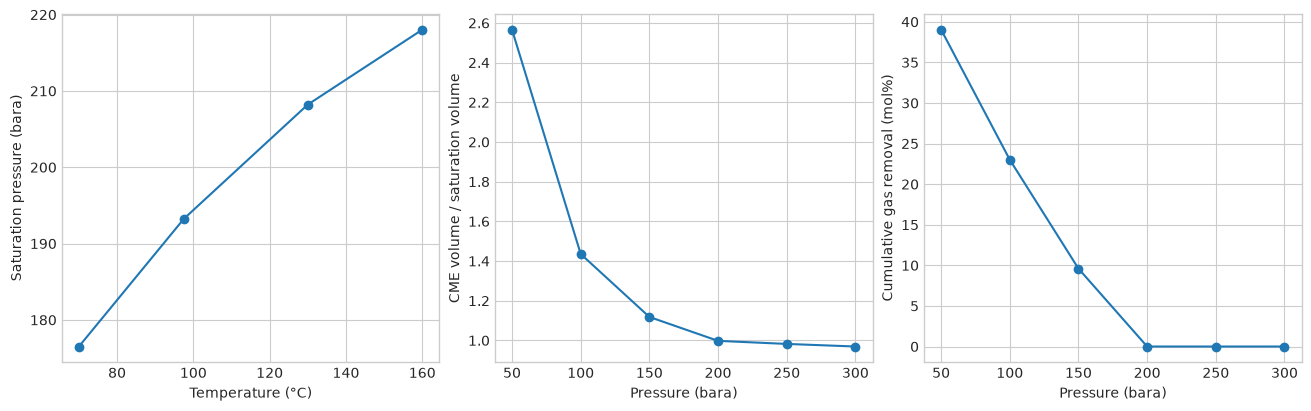

In [7]:
phase_figure, phase_axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
phase_axes[0].plot(
    saturation_results["temperature_C"],
    saturation_results["saturation_pressure_bara"], "o-",
)
phase_axes[0].set(xlabel="Temperature (°C)", ylabel="Saturation pressure (bara)")
phase_axes[1].plot(lab_pressures, lab_results["CME_relative_volume"], "o-")
phase_axes[1].set(xlabel="Pressure (bara)", ylabel="CME volume / saturation volume")
phase_axes[2].plot(lab_pressures, lab_results["CVD_removed_mol_percent"], "o-")
phase_axes[2].set(xlabel="Pressure (bara)", ylabel="Cumulative gas removal (mol%)")
plt.show()


## B. From a laboratory fluid to a reservoir forecast

The following coupling retains the existing synthetic sector model to make the new PVT study
comparable with the [original workbook](neqsim_opm_flow_blackoil_coupling.ipynb).
NeqSim resolves equilibrium molecular composition; this OPM case transports black-oil surface
components. It does not transport each EOS component or reproduce migration fractionation.
The CVD result is a laboratory comparison; the reservoir PVT handoff below uses differential
liberation. A research extension should compare a validated compositional reservoir case with
this black-oil reduction using the same measured assay and laboratory data.


## 2. Run differential liberation and assemble NeqSim PVT records

The DLE schedule removes equilibrium gas after each pressure step. The schedule includes points
above and below the bubble pressure, plus stock-tank pressure. Oil and gas viscosities are
calculated from flashed NeqSim states. Values above the bubble pressure retain the saturated
solution GOR and are later used only for the highest-$R_s$ undersaturated branch.

In [8]:
DifferentialLiberation = (
    jneqsim.pvtsimulation.simulation.DifferentialLiberation
)
dle = DifferentialLiberation(reservoir_fluid.clone())
dle.setPressures(DLE_PRESSURES_BARA.tolist())
dle.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
dle.runCalc()

bubble_pressure_bara = float(dle.getSaturationPressure())
dle_rs = np.asarray(dle.getRs(), dtype=float)
dle_bo = np.asarray(dle.getBo(), dtype=float)
dle_bg = np.asarray(dle.getBg(), dtype=float)
dle_oil_density_kg_m3 = np.asarray(dle.getOilDensity(), dtype=float)

saturation_gas_state = reservoir_fluid.clone()
saturation_gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_gas_state.setPressure(bubble_pressure_bara * 0.99, "bara")
TPflash(saturation_gas_state)
saturation_gas_state.initPhysicalProperties()
saturation_gas_viscosity_pa_s = (
    saturation_gas_state.getPhase("gas").getViscosity("cP") / 1000.0
)

black_oil_rows = []
for pressure_bara, rs_value, bo_value, bg_value, oil_density in zip(
    DLE_PRESSURES_BARA,
    dle_rs,
    dle_bo,
    dle_bg,
    dle_oil_density_kg_m3,
):
    property_state = reservoir_fluid.clone()
    property_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    property_state.setPressure(float(pressure_bara), "bara")
    TPflash(property_state)
    property_state.initPhysicalProperties()

    oil_viscosity_pa_s = (
        property_state.getPhase("oil").getViscosity("cP") / 1000.0
    )
    if property_state.hasPhaseType("gas"):
        gas_viscosity_pa_s = (
            property_state.getPhase("gas").getViscosity("cP") / 1000.0
        )
    else:
        gas_viscosity_pa_s = saturation_gas_viscosity_pa_s

    black_oil_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Rs_Sm3_Sm3": float(rs_value),
            "Bo_rm3_Sm3": float(bo_value),
            "oil_density_kg_m3": float(oil_density),
            "oil_viscosity_cP": 1000.0 * float(oil_viscosity_pa_s),
            "DLE_Bg_rm3_Sm3": float(bg_value),
            "gas_viscosity_cP": 1000.0 * float(gas_viscosity_pa_s),
        }
    )

black_oil_source_table = pd.DataFrame(black_oil_rows)
display(black_oil_source_table)
print(f"DLE bubble pressure: {bubble_pressure_bara:.6f} bara")

DLE bubble pressure: 193.240400 bara


,pressure_bara,Rs_Sm3_Sm3,Bo_rm3_Sm3,oil_density_kg_m3,oil_viscosity_cP,DLE_Bg_rm3_Sm3,gas_viscosity_cP
0,300.00000,224.672710,1.764295,669.030434,0.251013,0.000000,0.021248
1,250.00000,224.672710,1.789529,659.596213,0.235980,0.000000,0.021248
2,220.00000,224.672710,1.806786,653.296398,0.226502,0.000000,0.021248
3,200.00000,224.672710,1.819362,648.780648,0.219967,0.000000,0.021248
4,180.00000,209.018245,1.779299,654.830015,0.230365,0.006301,0.020399
5,150.00000,176.526156,1.687488,672.151168,0.263080,0.007562,0.018454
6,100.00000,128.971246,1.552728,701.626800,0.336558,0.011533,0.015971
7,50.00000,86.277567,1.427528,733.148154,0.461901,0.023873,0.014126
8,1.01325,0.000000,1.050859,810.424578,1.955226,1.271652,0.011572


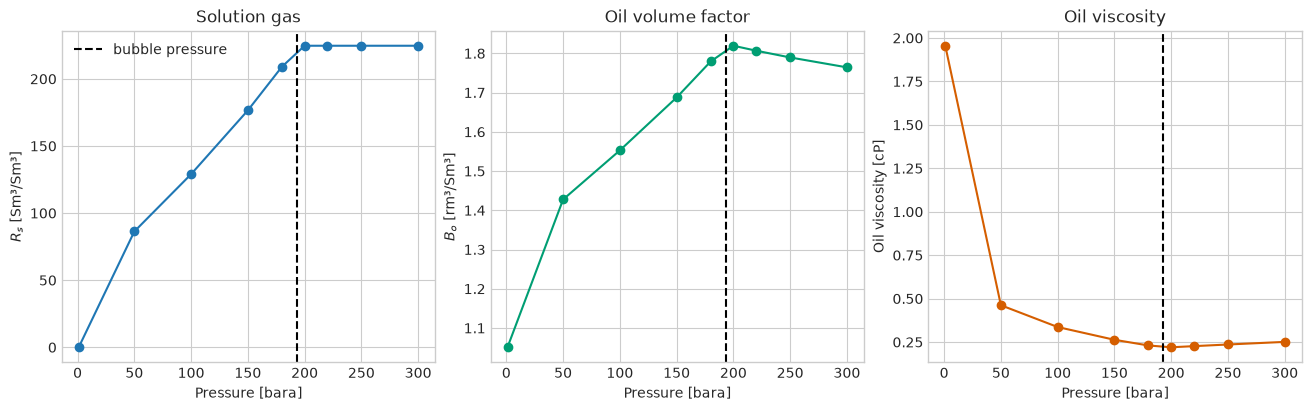

In [9]:
pvt_figure, pvt_axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 4.0),
    constrained_layout=True,
)

pvt_axes[0].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Rs_Sm3_Sm3"],
    marker="o",
)
pvt_axes[0].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="bubble pressure",
)
pvt_axes[0].set_xlabel("Pressure [bara]")
pvt_axes[0].set_ylabel("$R_s$ [Sm³/Sm³]")
pvt_axes[0].set_title("Solution gas")
pvt_axes[0].legend()

pvt_axes[1].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Bo_rm3_Sm3"],
    marker="o",
    color="#009E73",
)
pvt_axes[1].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
)
pvt_axes[1].set_xlabel("Pressure [bara]")
pvt_axes[1].set_ylabel("$B_o$ [rm³/Sm³]")
pvt_axes[1].set_title("Oil volume factor")

pvt_axes[2].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["oil_viscosity_cP"],
    marker="o",
    color="#D55E00",
)
pvt_axes[2].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
)
pvt_axes[2].set_xlabel("Pressure [bara]")
pvt_axes[2].set_ylabel("Oil viscosity [cP]")
pvt_axes[2].set_title("Oil viscosity")

pvt_plot_path = OUTPUT_DIRECTORY / "neqsim_black_oil_pvt.png"
pvt_figure.savefig(pvt_plot_path, dpi=150)
plt.show()

## 3. Create strict Flow-compatible `PVTO`, `PVDG`, and `PVTW`

NeqSim provides the thermodynamic records; the formatting below enforces OPM Flow's table
contracts:

- saturated `PVTO` rows increase in $R_s$ and bubble pressure;
- the highest-$R_s$ row contains an undersaturated continuation with decreasing $B_o$;
- `PVDG` pressure increases while $B_g$ decreases; and
- `PVTW` uses a CPA density derivative for water compressibility.

This explicit transformation is safer than assuming that any generic interpolated text export is
already a simulator-ready project deck.

In [10]:
stock_tank_state = reservoir_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initPhysicalProperties()

stock_oil_density_kg_m3 = (
    stock_tank_state.getPhase("oil").getDensity("kg/m3")
)
stock_gas_density_kg_m3 = (
    stock_tank_state.getPhase("gas").getDensity("kg/m3")
)

ArrayList = JClass("java.util.ArrayList")
BlackOilPVTTable = JClass("neqsim.blackoil.BlackOilPVTTable")
black_oil_records = ArrayList()
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    black_oil_records.add(
        BlackOilPVTTable.Record(
            row["pressure_bara"],
            row["Rs_Sm3_Sm3"],
            row["Bo_rm3_Sm3"],
            row["oil_viscosity_cP"] / 1000.0,
            max(row["DLE_Bg_rm3_Sm3"], 1.0e-6),
            row["gas_viscosity_cP"] / 1000.0,
            0.0,
            1.0,
            1.0e-3,
        )
    )

black_oil_table = BlackOilPVTTable(
    black_oil_records,
    bubble_pressure_bara,
)

bubble_bo = float(
    np.interp(
        bubble_pressure_bara,
        np.sort(DLE_PRESSURES_BARA),
        dle_bo[np.argsort(DLE_PRESSURES_BARA)],
    )
)
bubble_state = reservoir_fluid.clone()
bubble_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
bubble_state.setPressure(bubble_pressure_bara, "bara")
TPflash(bubble_state)
bubble_state.initPhysicalProperties()
bubble_oil_viscosity_cp = (
    bubble_state.getPhase("oil").getViscosity("cP")
)
maximum_solution_gor = float(np.max(dle_rs))

saturated_oil_rows = []
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    if row["pressure_bara"] >= bubble_pressure_bara:
        continue
    if (
        saturated_oil_rows
        and row["Rs_Sm3_Sm3"] <= saturated_oil_rows[-1]["Rs"]
    ):
        continue
    saturated_oil_rows.append(
        {
            "Rs": max(row["Rs_Sm3_Sm3"], 1.0e-6),
            "pressure": row["pressure_bara"],
            "Bo": row["Bo_rm3_Sm3"],
            "mu_o": row["oil_viscosity_cP"],
        }
    )

saturated_oil_rows.append(
    {
        "Rs": maximum_solution_gor,
        "pressure": bubble_pressure_bara,
        "Bo": bubble_bo,
        "mu_o": bubble_oil_viscosity_cp,
    }
)

maximum_pressure_row = black_oil_source_table.loc[
    black_oil_source_table["pressure_bara"].idxmax()
]
undersaturated_oil_row = {
    "pressure": float(maximum_pressure_row["pressure_bara"]),
    "Bo": float(maximum_pressure_row["Bo_rm3_Sm3"]),
    "mu_o": float(maximum_pressure_row["oil_viscosity_cP"]),
}

In [11]:
stock_gas_template = stock_tank_state.phaseToSystem("gas")
dry_gas_rows = []
for pressure_bara in GAS_PVT_PRESSURES_BARA:
    gas_state = stock_gas_template.clone()
    gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    gas_state.setPressure(float(pressure_bara), "bara")
    TPflash(gas_state)
    gas_state.initPhysicalProperties()
    gas_density_kg_m3 = gas_state.getPhase("gas").getDensity("kg/m3")
    dry_gas_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Bg_rm3_Sm3": (
                stock_gas_density_kg_m3 / gas_density_kg_m3
            ),
            "gas_viscosity_cP": (
                gas_state.getPhase("gas").getViscosity("cP")
            ),
        }
    )

dry_gas_table = pd.DataFrame(dry_gas_rows)


def build_water_state(temperature_c, pressure_bara):
    water_state = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    water_state.addComponent("water", 1.0)
    water_state.setMixingRule(10)
    TPflash(water_state)
    water_state.initPhysicalProperties()
    return water_state


standard_water_state = build_water_state(
    STANDARD_TEMPERATURE_C,
    STANDARD_PRESSURE_BARA,
)
reference_water_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara,
)
water_low_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara - 1.0,
)
water_high_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara + 1.0,
)

stock_water_density_kg_m3 = (
    standard_water_state.getPhase("aqueous").getDensity("kg/m3")
)
reservoir_water_density_kg_m3 = (
    reference_water_state.getPhase("aqueous").getDensity("kg/m3")
)
water_fvf = (
    stock_water_density_kg_m3 / reservoir_water_density_kg_m3
)
water_compressibility_per_bar = (
    water_high_pressure_state.getPhase("aqueous").getDensity("kg/m3")
    - water_low_pressure_state.getPhase("aqueous").getDensity("kg/m3")
) / (2.0 * reservoir_water_density_kg_m3)
water_viscosity_cp = (
    reference_water_state.getPhase("aqueous").getViscosity("cP")
)

display(dry_gas_table)
display(
    pd.DataFrame(
        {
            "water_property": [
                "stock-tank density",
                "reservoir density",
                "formation-volume factor",
                "compressibility",
                "viscosity",
            ],
            "value": [
                stock_water_density_kg_m3,
                reservoir_water_density_kg_m3,
                water_fvf,
                water_compressibility_per_bar,
                water_viscosity_cp,
            ],
            "unit": ["kg/m³", "kg/m³", "rm³/Sm³", "1/bar", "cP"],
        }
    )
)

,pressure_bara,Bg_rm3_Sm3,gas_viscosity_cP
0,1.01325,1.290646,0.012544
1,25.00000,0.049262,0.013143
2,50.00000,0.023145,0.014019
3,75.00000,0.014572,0.015213
4,100.00000,0.010446,0.016778
5,125.00000,0.008134,0.018700
6,150.00000,0.006733,0.020876
7,175.00000,0.005831,0.023164
8,200.00000,0.005216,0.025456
9,225.00000,0.004776,0.027697


,water_property,value,unit
0,stock-tank density,997.784768,kg/m³
1,reservoir density,978.587636,kg/m³
2,formation-volume factor,1.019617,rm³/Sm³
3,compressibility,0.000050,1/bar
4,viscosity,0.294506,cP


In [12]:
pvto_lines = ["PVTO"]
for row_index, row in enumerate(saturated_oil_rows):
    is_last_saturated_row = row_index == len(saturated_oil_rows) - 1
    row_suffix = "" if is_last_saturated_row else " /"
    pvto_lines.append(
        "  "
        f"{row['Rs']:.8f} "
        f"{row['pressure']:.8f} "
        f"{row['Bo']:.8f} "
        f"{row['mu_o']:.8f}"
        f"{row_suffix}"
    )
    if is_last_saturated_row:
        pvto_lines.append(
            "    "
            f"{undersaturated_oil_row['pressure']:.8f} "
            f"{undersaturated_oil_row['Bo']:.8f} "
            f"{undersaturated_oil_row['mu_o']:.8f} /"
        )
pvto_lines.append("/")

pvdg_lines = ["PVDG"]
for row_index, row in dry_gas_table.iterrows():
    row_suffix = " /" if row_index == len(dry_gas_table) - 1 else ""
    pvdg_lines.append(
        "  "
        f"{row['pressure_bara']:.8f} "
        f"{row['Bg_rm3_Sm3']:.10f} "
        f"{row['gas_viscosity_cP']:.8f}"
        f"{row_suffix}"
    )

black_oil_include = "\n".join(
    [
        "-- Flow-compatible black-oil tables calculated with NeqSim",
        "-- Pressure is absolute and the table unit system is METRIC.",
        "DENSITY",
        "  "
        f"{stock_oil_density_kg_m3:.8f} "
        f"{stock_water_density_kg_m3:.8f} "
        f"{stock_gas_density_kg_m3:.8f} /",
        "",
        *pvto_lines,
        "",
        *pvdg_lines,
        "",
        "PVTW",
        "  "
        f"{bubble_pressure_bara:.8f} "
        f"{water_fvf:.8f} "
        f"{water_compressibility_per_bar:.10e} "
        f"{water_viscosity_cp:.8f} "
        "0.0 /",
        "",
    ]
)

black_oil_path = OUTPUT_DIRECTORY / "NEQSIM_PVT.INC"
black_oil_path.write_text(black_oil_include, encoding="utf-8")

oil_table_audit = pd.DataFrame(saturated_oil_rows)
display(oil_table_audit)
print("\n".join(black_oil_include.splitlines()[:42]))
print(f"Black-oil include: {black_oil_path}")

-- Flow-compatible black-oil tables calculated with NeqSim
-- Pressure is absolute and the table unit system is METRIC.
DENSITY
  832.46987287 997.78476781 1.12375584 /

PVTO
  0.00000100 1.01325000 1.05085900 1.95522636 /
  86.27756659 50.00000000 1.42752753 0.46190091 /
  128.97124554 100.00000000 1.55272761 0.33655787 /
  176.52615626 150.00000000 1.68748770 0.26307966 /
  209.01824465 180.00000000 1.77929947 0.23036455 /
  224.67271009 193.24040031 1.80582153 0.21771608
    300.00000000 1.76429452 0.25101335 /
/

PVDG
  1.01325000 1.2906458622 0.01254417
  25.00000000 0.0492622652 0.01314293
  50.00000000 0.0231449092 0.01401858
  75.00000000 0.0145720509 0.01521278
  100.00000000 0.0104455093 0.01677753
  125.00000000 0.0081343925 0.01870015
  150.00000000 0.0067329734 0.02087585
  175.00000000 0.0058305684 0.02316351
  200.00000000 0.0052160944 0.02545613
  225.00000000 0.0047757014 0.02769676
  250.00000000 0.0044458169 0.02986229
  275.00000000 0.0041894725 0.03194685
  300.000

,Rs,pressure,Bo,mu_o
0,0.000001,1.01325,1.050859,1.955226
1,86.277567,50.00000,1.427528,0.461901
2,128.971246,100.00000,1.552728,0.336558
3,176.526156,150.00000,1.687488,0.263080
4,209.018245,180.00000,1.779299,0.230365
5,224.672710,193.24040,1.805822,0.217716


## 4. Build the OPM Flow sector model

The model has three permeability layers and 300 active cells. The producer and water injector are
completed in all layers. The injector is three grid columns from the producer so the three-year
forecast includes water breakthrough as well as pressure depletion and solution-gas evolution.

The production target is 1500 Sm³/day of oil until the 80 bara BHP limit becomes active. Water
injection is 300 Sm³/day with a 285 bara BHP ceiling.

In [13]:
relative_permeability_tables = """
SWOF
  0.12  0.00000  1.0000  0.0
  0.20  0.00010  0.8500  0.0
  0.30  0.00100  0.6200  0.0
  0.40  0.00800  0.4000  0.0
  0.50  0.03000  0.2200  0.0
  0.60  0.09000  0.1000  0.0
  0.70  0.22000  0.0300  0.0
  0.80  0.48000  0.0050  0.0
  0.88  1.00000  0.0000  0.0 /

SGOF
  0.00  0.0000  1.0000  0.0
  0.05  0.0020  0.9300  0.0
  0.10  0.0100  0.8000  0.0
  0.20  0.0600  0.5500  0.0
  0.30  0.1600  0.3200  0.0
  0.40  0.3300  0.1500  0.0
  0.50  0.5500  0.0500  0.0
  0.60  0.7800  0.0100  0.0
  0.70  0.9300  0.0010  0.0
  0.88  1.0000  0.0000  0.0 /
""".strip()

initial_rs_sm3_sm3 = saturated_oil_rows[-1]["Rs"]

deck_text = f"""
RUNSPEC
TITLE
  NEQSIM CHARACTERIZED BLACK-OIL MODEL WITH OPM FLOW

DIMENS
  10 10 3 /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2025 /

WELLDIMS
  2 3 1 2 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
DX
  300*100.0 /
DY
  300*100.0 /
DZ
  100*5.0 100*10.0 100*15.0 /
TOPS
  100*2500.0 /
PORO
  300*0.25 /
PERMX
  100*300.0 100*75.0 100*150.0 /
PERMY
  100*300.0 100*75.0 100*150.0 /
PERMZ
  100*30.0 100*7.5 100*15.0 /

PROPS
INCLUDE
  'NEQSIM_PVT.INC' /

ROCK
  260.0 4.0E-5 /

{relative_permeability_tables}

SOLUTION
EQUIL
  2500.0 260.0 2550.0 0.0 2450.0 0.0 1 0 0 /

RSVD
  2450.0 {initial_rs_sm3_sm3:.8f}
  2550.0 {initial_rs_sm3_sm3:.8f} /

SUMMARY
FPR
FOPR
FGPR
FWPR
FOPT
FGPT
FWPT
WBHP
  'PROD' /
WOPR
  'PROD' /
WGPR
  'PROD' /
WWPR
  'PROD' /
WGOR
  'PROD' /

SCHEDULE
RPTRST
  'BASIC=1' /

GRUPTREE
  'WELLS' 'FIELD' /
/

WELSPECS
  'PROD' 'WELLS' 10 10 2515.0 'OIL' /
  'WINJ' 'WELLS' 7 10 2503.0 'WATER' /
/

COMPDAT
  'PROD' 10 10 1 3 'OPEN' 1* 1* 0.20 /
  'WINJ' 7 10 1 3 'OPEN' 1* 1* 0.20 /
/

WCONPROD
  'PROD' 'OPEN' 'ORAT' 1500.0 4* 80.0 /
/

WCONINJE
  'WINJ' 'WATER' 'OPEN' 'RATE' 300.0 1* 285.0 /
/

TSTEP
  36*30.4375 /

END
""".strip()

deck_path = OUTPUT_DIRECTORY / "NEQSIM_OPM.DATA"
deck_path.write_text(deck_text + "\n", encoding="utf-8")
print(f"Flow deck: {deck_path}")
print(f"Deck lines: {len(deck_text.splitlines())}")

Flow deck: phase_evolution_opm_outputs/NEQSIM_OPM.DATA
Deck lines: 133


In [14]:
parsed_deck = Parser().parse(str(deck_path))
required_deck_keywords = [
    "DIMENS",
    "DENSITY",
    "PVTO",
    "PVDG",
    "PVTW",
    "EQUIL",
    "WELSPECS",
    "WCONPROD",
    "WCONINJE",
]
deck_keyword_audit = pd.DataFrame(
    {
        "keyword": required_deck_keywords,
        "present": [
            keyword in parsed_deck
            for keyword in required_deck_keywords
        ],
    }
)

oil_rs_values = oil_table_audit["Rs"].to_numpy()
oil_bubble_pressures = oil_table_audit["pressure"].to_numpy()
gas_pressures = dry_gas_table["pressure_bara"].to_numpy()
gas_bg_values = dry_gas_table["Bg_rm3_Sm3"].to_numpy()

pvt_contract_audit = pd.DataFrame(
    {
        "contract": [
            "saturated Rs strictly increases",
            "bubble pressure strictly increases",
            "dry-gas pressure strictly increases",
            "dry-gas Bg strictly decreases",
            "undersaturated Bo decreases with pressure",
            "undersaturated viscosity increases with pressure",
            "no invalid numeric tokens",
        ],
        "passed": [
            np.all(np.diff(oil_rs_values) > 0.0),
            np.all(np.diff(oil_bubble_pressures) > 0.0),
            np.all(np.diff(gas_pressures) > 0.0),
            np.all(np.diff(gas_bg_values) < 0.0),
            undersaturated_oil_row["Bo"] < saturated_oil_rows[-1]["Bo"],
            (
                undersaturated_oil_row["mu_o"]
                > saturated_oil_rows[-1]["mu_o"]
            ),
            not any(
                token in black_oil_include
                for token in ["NaN", "Infinity", "-Infinity"]
            ),
        ],
    }
)

display(deck_keyword_audit)
display(pvt_contract_audit)
print(f"OPM parser accepted {len(parsed_deck)} deck keywords.")

OPM parser accepted 55 deck keywords.


,keyword,present
0,DIMENS,True
1,DENSITY,True
2,PVTO,True
3,PVDG,True
4,PVTW,True
5,EQUIL,True
6,WELSPECS,True
7,WCONPROD,True
8,WCONINJE,True


,contract,passed
0,saturated Rs strictly increases,True
1,bubble pressure strictly increases,True
2,dry-gas pressure strictly increases,True
3,dry-gas Bg strictly decreases,True
4,undersaturated Bo decreases with pressure,True
5,undersaturated viscosity increases with pressure,True
6,no invalid numeric tokens,True


## 5. Run OPM Flow and retain convergence evidence

Flow reads the deck and the NeqSim-generated include from the output directory. The process return
code, report-step count, Newton information, and simulator timing are retained. The full `.PRT`,
restart, grid, and summary files remain available in the runtime output directory.

In [15]:
flow_run = subprocess.run(
    [FLOW_EXECUTABLE, deck_path.name],
    cwd=OUTPUT_DIRECTORY,
    env=FLOW_RUN_ENV,
    capture_output=True,
    text=True,
    timeout=300,
)

if flow_run.returncode != 0:
    raise RuntimeError(
        "OPM Flow failed:\n"
        + flow_run.stdout[-5000:]
        + "\n"
        + flow_run.stderr[-3000:]
    )

flow_stdout_lines = flow_run.stdout.splitlines()
flow_log_tail = "\n".join(flow_stdout_lines[-24:])
report_step_count = sum(
    "Report step" in output_line
    for output_line in flow_stdout_lines
)
simulation_time_match = re.search(
    r"(?:Simulation time:\s+([0-9.]+)\s+s|"
    r"Total time \(seconds\):\s+([0-9.]+))",
    flow_run.stdout,
)
simulation_time_seconds = (
    float(
        simulation_time_match.group(1)
        or simulation_time_match.group(2)
    )
    if simulation_time_match
    else np.nan
)

flow_diagnostics = pd.DataFrame(
    {
        "diagnostic": [
            "return code",
            "reported report steps",
            "simulation time",
            "SMSPEC exists",
            "PRT exists",
        ],
        "value": [
            flow_run.returncode,
            report_step_count,
            simulation_time_seconds,
            (OUTPUT_DIRECTORY / "NEQSIM_OPM.SMSPEC").exists(),
            (OUTPUT_DIRECTORY / "NEQSIM_OPM.PRT").exists(),
        ],
        "unit": ["-", "count", "s", "boolean", "boolean"],
    }
)
display(flow_diagnostics)
print(flow_log_tail)

Restart file written for report step 35/36, date = 02-Dec-2027 07:30:00
 Newton its= 2, linearizations= 3 (0.0sec), linear its=  2 (0.0sec)
Restart file written for report step 36/36, date = 01-Jan-2028 18:00:00


================    End of simulation     ===============

Number of MPI processes:         1
Threads per MPI process:         1
Setup time:                      0.05 s
  Deck input:                    0.04 s
Number of timesteps:            41
Simulation time:                 0.31 s
  Assembly time:                 0.07 s (Wasted: 0.0 s; 0.0%)
    Well assembly:               0.02 s (Wasted: 0.0 s; 0.0%)
  Linear solve time:             0.17 s (Wasted: 0.0 s; 0.0%)
    Linear setup:                0.13 s (Wasted: 0.0 s; 0.0%)
  Props/update time:             0.03 s (Wasted: 0.0 s; 0.0%)
  Pre/post step:                 0.03 s (Wasted: 0.0 s; 0.0%)
  Output write time:             0.01 s
Overall Linearizations:        160      (Wasted:     0; 0.0%)
Overall Newton Iterations:  

,diagnostic,value,unit
0,return code,0,-
1,reported report steps,36,count
2,simulation time,0.31,s
3,SMSPEC exists,True,boolean
4,PRT exists,True,boolean


In [16]:
summary_path = OUTPUT_DIRECTORY / "NEQSIM_OPM.SMSPEC"
flow_summary = ESmry(str(summary_path))


def summary_values(key):
    return np.asarray(flow_summary[key], dtype=float)


summary_dates = pd.to_datetime(flow_summary.dates())
reservoir_history = pd.DataFrame(
    {
        "date": summary_dates,
        "time_days": summary_values("TIME"),
        "field_pressure_bara": summary_values("FPR"),
        "oil_rate_Sm3_day": summary_values("FOPR"),
        "gas_rate_Sm3_day": summary_values("FGPR"),
        "water_rate_Sm3_day": summary_values("FWPR"),
        "cumulative_oil_MSm3": summary_values("FOPT") / 1.0e6,
        "cumulative_gas_GSm3": summary_values("FGPT") / 1.0e9,
        "cumulative_water_MSm3": summary_values("FWPT") / 1.0e6,
        "producer_bhp_bara": summary_values("WBHP:PROD"),
        "well_gor_Sm3_Sm3": summary_values("WGOR:PROD"),
    }
)

display(reservoir_history.head(4).T)
display(reservoir_history.tail(4).T)
print(f"Summary vectors: {len(flow_summary.keys())}")
print(f"Stored report states: {len(reservoir_history)}")

Summary vectors: 14
Stored report states: 41


,0,1,2,3
date,2025-01-02 00:00:00,2025-01-05 00:00:00,2025-01-12 05:39:45,2025-01-21 20:04:52
time_days,1.0,4.0,11.235946,20.836723
field_pressure_bara,259.567627,255.57843,245.947769,233.150452
oil_rate_Sm3_day,1500.0,1500.0,1500.0,1500.0
gas_rate_Sm3_day,337009.0625,337009.0625,337009.0625,337009.0625
water_rate_Sm3_day,0.000456,0.000685,0.000965,0.001296
cumulative_oil_MSm3,0.0015,0.006,0.016854,0.031255
cumulative_gas_GSm3,0.000337,0.001348,0.003787,0.007022
cumulative_water_MSm3,0.0,0.0,0.0,0.0
producer_bhp_bara,230.941788,222.670746,212.37944,199.839035


,37,38,39,40
date,2027-10-02 11:30:00,2027-11-01 22:00:00,2027-12-02 07:30:00,2028-01-01 18:00:00
time_days,1004.4375,1034.875,1065.3125,1095.75
field_pressure_bara,90.963753,90.418388,89.926949,89.481094
oil_rate_Sm3_day,65.44561,60.838688,56.59676,52.647923
gas_rate_Sm3_day,95305.664062,87899.640625,81349.523438,75749.578125
water_rate_Sm3_day,44.053684,44.147778,44.188976,44.181877
cumulative_oil_MSm3,0.664249,0.6661,0.667823,0.669426
cumulative_gas_GSm3,0.327289,0.329964,0.33244,0.334746
cumulative_water_MSm3,0.017739,0.019083,0.020428,0.021772
producer_bhp_bara,80.0,80.0,80.0,80.0


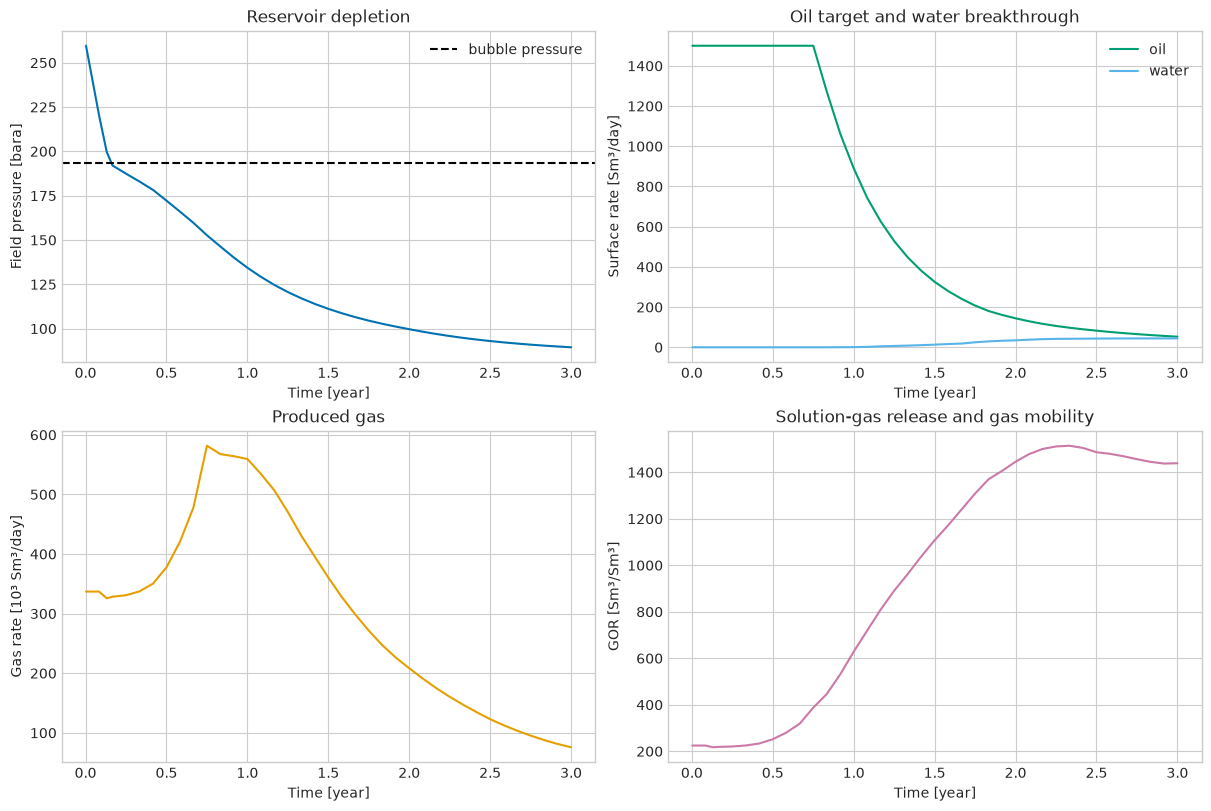

In [17]:
reservoir_figure, reservoir_axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 8.0),
    constrained_layout=True,
)

reservoir_axes[0, 0].plot(
    reservoir_history["time_days"] / 365.25,
    reservoir_history["field_pressure_bara"],
    color="#0072B2",
)
reservoir_axes[0, 0].axhline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="bubble pressure",
)
reservoir_axes[0, 0].set_xlabel("Time [year]")
reservoir_axes[0, 0].set_ylabel("Field pressure [bara]")
reservoir_axes[0, 0].set_title("Reservoir depletion")
reservoir_axes[0, 0].legend()

reservoir_axes[0, 1].plot(
    reservoir_history["time_days"] / 365.25,
    reservoir_history["oil_rate_Sm3_day"],
    label="oil",
    color="#009E73",
)
reservoir_axes[0, 1].plot(
    reservoir_history["time_days"] / 365.25,
    reservoir_history["water_rate_Sm3_day"],
    label="water",
    color="#56B4E9",
)
reservoir_axes[0, 1].set_xlabel("Time [year]")
reservoir_axes[0, 1].set_ylabel("Surface rate [Sm³/day]")
reservoir_axes[0, 1].set_title("Oil target and water breakthrough")
reservoir_axes[0, 1].legend()

reservoir_axes[1, 0].plot(
    reservoir_history["time_days"] / 365.25,
    reservoir_history["gas_rate_Sm3_day"] / 1000.0,
    color="#E69F00",
)
reservoir_axes[1, 0].set_xlabel("Time [year]")
reservoir_axes[1, 0].set_ylabel("Gas rate [10³ Sm³/day]")
reservoir_axes[1, 0].set_title("Produced gas")

reservoir_axes[1, 1].plot(
    reservoir_history["time_days"] / 365.25,
    reservoir_history["well_gor_Sm3_Sm3"],
    color="#CC79A7",
    label="GOR",
)
reservoir_axes[1, 1].set_xlabel("Time [year]")
reservoir_axes[1, 1].set_ylabel("GOR [Sm³/Sm³]")
reservoir_axes[1, 1].set_title("Solution-gas release and gas mobility")

reservoir_plot_path = OUTPUT_DIRECTORY / "opm_flow_forecast.png"
reservoir_figure.savefig(reservoir_plot_path, dpi=150)
plt.show()

## 6. Visualize the reservoir mesh and simulated cell states

OPM writes the grid geometry to `EGRID`, static rock properties to `INIT`, and dynamic cell
states to `UNRST`. The next graphics read those files directly. The three-dimensional view shows
the 300 active cells, layer permeability, and completed producer and injector trajectories. The
state maps show final pressure, water saturation, and gas saturation for every layer.

Depth is vertically exaggerated in the mesh view so the three layers remain visible. Property
maps retain the actual 100 m × 100 m cell dimensions.

In [18]:
grid_path = OUTPUT_DIRECTORY / "NEQSIM_OPM.EGRID"
initialization_path = OUTPUT_DIRECTORY / "NEQSIM_OPM.INIT"
restart_path = OUTPUT_DIRECTORY / "NEQSIM_OPM.UNRST"

reservoir_grid = EGrid(str(grid_path))
initialization_file = EclFile(str(initialization_path))
restart_file = ERst(str(restart_path))

grid_nx, grid_ny, grid_nz = [
    int(dimension_value)
    for dimension_value in reservoir_grid.dimension
]
active_cell_count = int(reservoir_grid.active_cells)
restart_steps = [int(report_step) for report_step in restart_file.report_steps]
final_restart_step = restart_steps[-1]


def active_array_to_cube(active_values):
    active_array = np.asarray(active_values, dtype=float)
    return active_array.reshape(grid_nz, grid_ny, grid_nx)


permeability_cube_md = active_array_to_cube(
    initialization_file["PERMX"]
)
final_pressure_cube_bara = active_array_to_cube(
    restart_file["PRESSURE", final_restart_step]
)
final_water_saturation_cube = active_array_to_cube(
    restart_file["SWAT", final_restart_step]
)
final_gas_saturation_cube = active_array_to_cube(
    restart_file["SGAS", final_restart_step]
)
final_oil_saturation_cube = (
    1.0
    - final_water_saturation_cube
    - final_gas_saturation_cube
)

cell_x_min_m = []
cell_y_min_m = []
cell_top_depth_m = []
cell_dx_m = []
cell_dy_m = []
cell_thickness_m = []
for active_index in range(active_cell_count):
    x_corners, y_corners, z_corners = (
        reservoir_grid.xyz_from_active_index(active_index)
    )
    cell_x_min_m.append(min(x_corners))
    cell_y_min_m.append(min(y_corners))
    cell_top_depth_m.append(min(z_corners))
    cell_dx_m.append(max(x_corners) - min(x_corners))
    cell_dy_m.append(max(y_corners) - min(y_corners))
    cell_thickness_m.append(max(z_corners) - min(z_corners))

cell_x_min_m = np.asarray(cell_x_min_m)
cell_y_min_m = np.asarray(cell_y_min_m)
cell_top_depth_m = np.asarray(cell_top_depth_m)
cell_dx_m = np.asarray(cell_dx_m)
cell_dy_m = np.asarray(cell_dy_m)
cell_thickness_m = np.asarray(cell_thickness_m)
permeability_active_md = np.asarray(
    initialization_file["PERMX"],
    dtype=float,
)

restart_state_audit = pd.DataFrame(
    {
        "quantity": [
            "grid dimensions",
            "active cells",
            "restart report steps",
            "final pressure range",
            "final water-saturation range",
            "final gas-saturation range",
            "final oil-saturation minimum",
        ],
        "value": [
            f"{grid_nx} × {grid_ny} × {grid_nz}",
            active_cell_count,
            len(restart_steps),
            (
                f"{final_pressure_cube_bara.min():.3f} to "
                f"{final_pressure_cube_bara.max():.3f}"
            ),
            (
                f"{final_water_saturation_cube.min():.4f} to "
                f"{final_water_saturation_cube.max():.4f}"
            ),
            (
                f"{final_gas_saturation_cube.min():.4f} to "
                f"{final_gas_saturation_cube.max():.4f}"
            ),
            f"{final_oil_saturation_cube.min():.4f}",
        ],
        "unit": [
            "cells",
            "count",
            "count",
            "bara",
            "fraction",
            "fraction",
            "fraction",
        ],
    }
)
display(restart_state_audit)

,quantity,value,unit
0,grid dimensions,10 × 10 × 3,cells
1,active cells,300,count
2,restart report steps,37,count
3,final pressure range,85.622 to 93.222,bara
4,final water-saturation range,0.1218 to 0.8135,fraction
5,final gas-saturation range,0.0022 to 0.6171,fraction
6,final oil-saturation minimum,0.1843,fraction


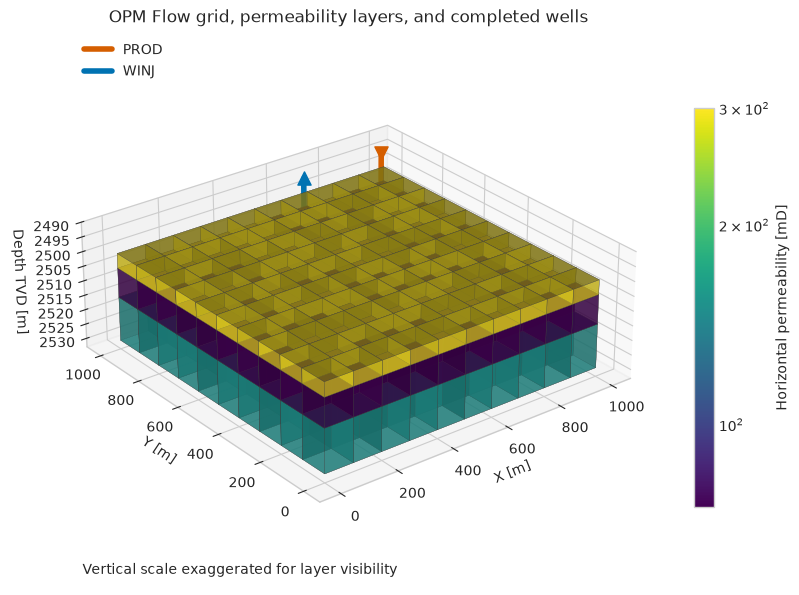

In [19]:
mesh_figure = plt.figure(figsize=(11.0, 7.2))
mesh_axis = mesh_figure.add_subplot(111, projection="3d")

permeability_norm = LogNorm(
    vmin=permeability_active_md.min(),
    vmax=permeability_active_md.max(),
)
cell_colors = plt.cm.viridis(
    permeability_norm(permeability_active_md)
)
cell_colors[:, 3] = 0.62

mesh_axis.bar3d(
    cell_x_min_m,
    cell_y_min_m,
    cell_top_depth_m,
    cell_dx_m,
    cell_dy_m,
    cell_thickness_m,
    color=cell_colors,
    edgecolor="#404040",
    linewidth=0.18,
    shade=True,
)

well_trajectories = [
    {
        "name": "PROD",
        "x_m": 950.0,
        "y_m": 950.0,
        "color": "#D55E00",
        "marker": "v",
    },
    {
        "name": "WINJ",
        "x_m": 650.0,
        "y_m": 950.0,
        "color": "#0072B2",
        "marker": "^",
    },
]
minimum_depth_m = cell_top_depth_m.min()
maximum_depth_m = (
    cell_top_depth_m + cell_thickness_m
).max()
for well_definition in well_trajectories:
    mesh_axis.plot(
        [well_definition["x_m"], well_definition["x_m"]],
        [well_definition["y_m"], well_definition["y_m"]],
        [minimum_depth_m - 8.0, maximum_depth_m + 2.0],
        color=well_definition["color"],
        linewidth=4.0,
        label=well_definition["name"],
    )
    mesh_axis.scatter(
        [well_definition["x_m"]],
        [well_definition["y_m"]],
        [minimum_depth_m - 8.0],
        color=well_definition["color"],
        marker=well_definition["marker"],
        s=90,
        depthshade=False,
    )

permeability_scalar_map = plt.cm.ScalarMappable(
    norm=permeability_norm,
    cmap="viridis",
)
permeability_scalar_map.set_array([])
mesh_colorbar = mesh_figure.colorbar(
    permeability_scalar_map,
    ax=mesh_axis,
    shrink=0.72,
    pad=0.08,
)
mesh_colorbar.set_label("Horizontal permeability [mD]")

mesh_axis.set_xlabel("X [m]")
mesh_axis.set_ylabel("Y [m]")
mesh_axis.set_zlabel("Depth TVD [m]")
mesh_axis.set_title(
    "OPM Flow grid, permeability layers, and completed wells"
)
mesh_axis.set_box_aspect((1.0, 1.0, 0.36))
mesh_axis.set_zlim(maximum_depth_m + 3.0, minimum_depth_m - 10.0)
mesh_axis.view_init(elev=27.0, azim=-128.0)
mesh_axis.legend(loc="upper left")
mesh_axis.text2D(
    0.02,
    0.02,
    "Vertical scale exaggerated for layer visibility",
    transform=mesh_axis.transAxes,
)

mesh_plot_path = OUTPUT_DIRECTORY / "opm_reservoir_mesh.png"
mesh_figure.savefig(
    mesh_plot_path,
    dpi=170,
    bbox_inches="tight",
)
plt.show()

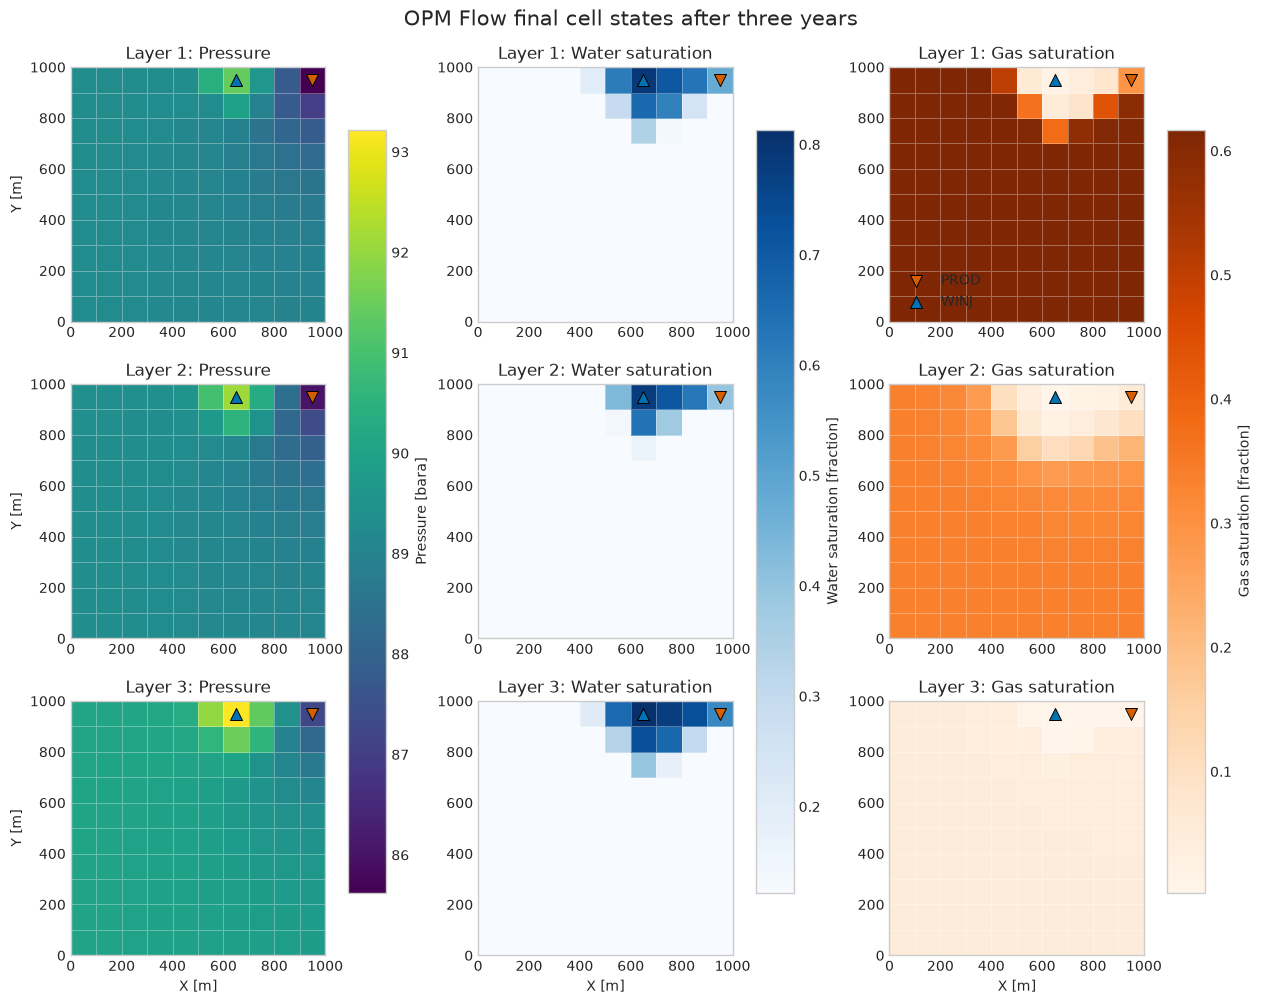

In [20]:
state_map_figure, state_map_axes = plt.subplots(
    grid_nz,
    3,
    figsize=(12.5, 10.0),
    constrained_layout=True,
)

state_properties = [
    {
        "cube": final_pressure_cube_bara,
        "title": "Pressure",
        "unit": "bara",
        "cmap": "viridis",
    },
    {
        "cube": final_water_saturation_cube,
        "title": "Water saturation",
        "unit": "fraction",
        "cmap": "Blues",
    },
    {
        "cube": final_gas_saturation_cube,
        "title": "Gas saturation",
        "unit": "fraction",
        "cmap": "Oranges",
    },
]

cell_edges_x_m = np.linspace(0.0, 1000.0, grid_nx + 1)
cell_edges_y_m = np.linspace(0.0, 1000.0, grid_ny + 1)
column_images = []
for property_index, property_definition in enumerate(
    state_properties
):
    property_cube = property_definition["cube"]
    column_minimum = property_cube.min()
    column_maximum = property_cube.max()
    for layer_index in range(grid_nz):
        state_axis = state_map_axes[layer_index, property_index]
        state_image = state_axis.pcolormesh(
            cell_edges_x_m,
            cell_edges_y_m,
            property_cube[layer_index],
            cmap=property_definition["cmap"],
            vmin=column_minimum,
            vmax=column_maximum,
            edgecolors=(1.0, 1.0, 1.0, 0.32),
            linewidth=0.55,
            shading="flat",
        )
        if layer_index == 0:
            column_images.append(state_image)
        state_axis.scatter(
            [950.0],
            [950.0],
            marker="v",
            s=75,
            color="#D55E00",
            edgecolor="black",
            linewidth=0.7,
            label="PROD",
        )
        state_axis.scatter(
            [650.0],
            [950.0],
            marker="^",
            s=75,
            color="#0072B2",
            edgecolor="black",
            linewidth=0.7,
            label="WINJ",
        )
        state_axis.set_aspect("equal")
        state_axis.set_xlim(0.0, 1000.0)
        state_axis.set_ylim(0.0, 1000.0)
        state_axis.set_title(
            f"Layer {layer_index + 1}: "
            f"{property_definition['title']}"
        )
        if property_index == 0:
            state_axis.set_ylabel("Y [m]")
        if layer_index == grid_nz - 1:
            state_axis.set_xlabel("X [m]")

for property_index, property_definition in enumerate(
    state_properties
):
    state_colorbar = state_map_figure.colorbar(
        column_images[property_index],
        ax=state_map_axes[:, property_index],
        shrink=0.83,
        pad=0.02,
    )
    state_colorbar.set_label(
        f"{property_definition['title']} "
        f"[{property_definition['unit']}]"
    )

state_map_axes[0, 2].legend(
    loc="lower left",
    framealpha=0.92,
)
state_map_figure.suptitle(
    "OPM Flow final cell states after three years",
    fontsize=15,
)

state_map_path = OUTPUT_DIRECTORY / "opm_final_cell_state_maps.png"
state_map_figure.savefig(
    state_map_path,
    dpi=165,
    bbox_inches="tight",
)
plt.show()

## 7. Identify operating milestones

The key transitions for surface facilities are not only calendar dates. They are the first bubble
pressure crossing, the start of BHP-limited production, the onset of produced water, and the peak
gas rate. These events are calculated from the Flow summary vectors and become candidate design
cases for the NeqSim process.

In [21]:
def first_matching_index(mask):
    matching_indices = np.flatnonzero(np.asarray(mask, dtype=bool))
    return int(matching_indices[0]) if len(matching_indices) else None


bubble_crossing_index = first_matching_index(
    reservoir_history["field_pressure_bara"] <= bubble_pressure_bara
)
bhp_limited_index = first_matching_index(
    reservoir_history["producer_bhp_bara"]
    <= PRODUCER_BHP_LIMIT_BARA + 1.0e-3
)
water_breakthrough_index = first_matching_index(
    reservoir_history["water_rate_Sm3_day"] >= 1.0
)
peak_gas_index = int(
    reservoir_history["gas_rate_Sm3_day"].idxmax()
)

milestone_indices = {
    "bubble-pressure crossing": bubble_crossing_index,
    "BHP constraint active": bhp_limited_index,
    "water rate above 1 Sm3/day": water_breakthrough_index,
    "peak gas rate": peak_gas_index,
}

milestone_rows = []
for milestone_name, row_index in milestone_indices.items():
    if row_index is None:
        continue
    history_row = reservoir_history.iloc[row_index]
    milestone_rows.append(
        {
            "milestone": milestone_name,
            "time_year": history_row["time_days"] / 365.25,
            "pressure_bara": history_row["field_pressure_bara"],
            "oil_rate_Sm3_day": history_row["oil_rate_Sm3_day"],
            "gas_rate_kSm3_day": (
                history_row["gas_rate_Sm3_day"] / 1000.0
            ),
            "water_rate_Sm3_day": history_row["water_rate_Sm3_day"],
            "GOR_Sm3_Sm3": history_row["well_gor_Sm3_Sm3"],
        }
    )

milestone_table = pd.DataFrame(milestone_rows)
display(milestone_table.set_index("milestone").T)

milestone,bubble-pressure crossing,BHP constraint active,water rate above 1 Sm3/day,peak gas rate
time_year,0.166667,0.833333,1.083333,0.750000
pressure_bara,191.985641,146.286026,129.240509,152.671326
oil_rate_Sm3_day,1500.000000,1272.128052,742.932434,1500.000488
gas_rate_kSm3_day,328.386281,567.662500,534.551875,581.693688
water_rate_Sm3_day,0.002781,0.096517,2.117201,0.042821
GOR_Sm3_Sm3,218.924179,446.230652,719.516113,387.795654


## 8. Convert black-oil production back to characterized NeqSim flows

Flow reports standard oil, gas, and water rates. Let $\mathbf{n}_o$ and $\mathbf{n}_g$ be the
NeqSim component molar-flow vectors for one standard cubic metre of stock-tank oil and surface
gas. The reconstructed hydrocarbon flow is

$$\dot{\mathbf{n}}_{\mathrm{HC}}
= q_{o,\mathrm{sc}}\mathbf{n}_o
+ q_{g,\mathrm{sc}}\mathbf{n}_g.$$

Produced water is added from `WWPR`, and the combined material is flashed at wellhead pressure
and temperature:

$$\dot m_{\mathrm{feed}}
= \dot m_o + \dot m_g + \dot m_w.$$

The stock-component compositions come from the same characterized NeqSim fluid that generated
the PVT tables. Changing Flow GOR therefore changes the reconstructed overall composition while
retaining all 22 hydrocarbon component identities.

In [22]:
stock_oil_template = stock_tank_state.phaseToSystem("oil")
stock_gas_template = stock_tank_state.phaseToSystem("gas")

water_probe = jneqsim.thermo.system.SystemSrkEos(
    STANDARD_TEMPERATURE_C + 273.15,
    STANDARD_PRESSURE_BARA,
)
water_probe.addComponent("water", 1.0)
water_molar_mass_kg_mol = (
    water_probe.getComponent("water").getMolarMass()
)


def reconstruct_characterized_wellhead_fluid(
    oil_rate_sm3_day,
    gas_rate_sm3_day,
    water_rate_sm3_day,
    wellhead_temperature_c=65.0,
    wellhead_pressure_bara=70.0,
):
    stock_oil = stock_oil_template.clone()
    stock_gas = stock_gas_template.clone()
    stock_oil.setTotalFlowRate(float(oil_rate_sm3_day), "m3/day")
    stock_gas.setTotalFlowRate(float(gas_rate_sm3_day), "Sm3/day")

    clearProcess()
    oil_component_stream = stream(
        "Black-oil stock-tank oil component",
        stock_oil,
    )
    gas_component_stream = stream(
        "Black-oil surface-gas component",
        stock_gas,
    )
    recombination_mixer = mixer(
        "Black-oil to characterized-fluid recombination"
    )
    recombination_mixer.addStream(oil_component_stream)
    recombination_mixer.addStream(gas_component_stream)
    runProcess()

    reconstructed_fluid = (
        recombination_mixer.getOutletStream().getFluid().clone()
    )
    hydrocarbon_mass_flow_kg_s = (
        reconstructed_fluid.getFlowRate("kg/sec")
    )
    water_mass_flow_kg_s = (
        float(water_rate_sm3_day)
        * stock_water_density_kg_m3
        / SECONDS_PER_DAY
    )
    water_molar_flow_mol_s = (
        water_mass_flow_kg_s / water_molar_mass_kg_mol
    )

    reconstructed_fluid.addComponent(
        "water",
        water_molar_flow_mol_s,
    )
    reconstructed_fluid.setMixingRule("classic")
    reconstructed_fluid.setMultiPhaseCheck(True)
    reconstructed_fluid.setTemperature(
        wellhead_temperature_c,
        "C",
    )
    reconstructed_fluid.setPressure(
        wellhead_pressure_bara,
        "bara",
    )
    TPflash(reconstructed_fluid)
    reconstructed_fluid.initPhysicalProperties()

    expected_mass_flow_kg_s = (
        hydrocarbon_mass_flow_kg_s + water_mass_flow_kg_s
    )
    audit = {
        "expected_mass_flow_kg_s": expected_mass_flow_kg_s,
        "calculated_mass_flow_kg_s": (
            reconstructed_fluid.getFlowRate("kg/sec")
        ),
        "mass_residual_kg_s": (
            reconstructed_fluid.getFlowRate("kg/sec")
            - expected_mass_flow_kg_s
        ),
    }
    return reconstructed_fluid, audit

In [23]:
snapshot_indices = [
    0,
    bubble_crossing_index,
    len(reservoir_history) - 1,
]
snapshot_labels = [
    "early plateau",
    "bubble crossing",
    "late water-producing case",
]

snapshot_rows = []
snapshot_fluids = {}
for snapshot_label, row_index in zip(
    snapshot_labels,
    snapshot_indices,
):
    history_row = reservoir_history.iloc[row_index]
    snapshot_fluid, snapshot_audit = (
        reconstruct_characterized_wellhead_fluid(
            history_row["oil_rate_Sm3_day"],
            history_row["gas_rate_Sm3_day"],
            history_row["water_rate_Sm3_day"],
        )
    )
    snapshot_fluids[snapshot_label] = snapshot_fluid

    heavy_mole_fraction = sum(
        snapshot_fluid.getComponent(component_index).getz()
        for component_index in range(
            snapshot_fluid.getNumberOfComponents()
        )
        if (
            snapshot_fluid.getComponent(
                component_index
            ).getMolarMass()
            > 0.090
        )
    )
    phase_types = [
        str(snapshot_fluid.getPhase(phase_index).getPhaseTypeName())
        for phase_index in range(snapshot_fluid.getNumberOfPhases())
    ]
    snapshot_rows.append(
        {
            "case": snapshot_label,
            "time_year": history_row["time_days"] / 365.25,
            "GOR_Sm3_Sm3": history_row["well_gor_Sm3_Sm3"],
            "water_rate_Sm3_day": history_row["water_rate_Sm3_day"],
            "mass_flow_kg_s": snapshot_fluid.getFlowRate("kg/sec"),
            "methane_mole_fraction": (
                snapshot_fluid.getComponent("methane").getz()
            ),
            "heavy_mole_fraction": heavy_mole_fraction,
            "water_mole_fraction": (
                snapshot_fluid.getComponent("water").getz()
            ),
            "component_count": snapshot_fluid.getNumberOfComponents(),
            "phases_at_wellhead": ", ".join(phase_types),
            "mass_residual_kg_s": snapshot_audit[
                "mass_residual_kg_s"
            ],
        }
    )

characterized_snapshot_table = pd.DataFrame(snapshot_rows)
display(characterized_snapshot_table.set_index("case").T)

case,early plateau,bubble crossing,late water-producing case
time_year,0.002738,0.166667,3.0
GOR_Sm3_Sm3,224.672714,218.924179,1438.795166
water_rate_Sm3_day,0.000456,0.002781,44.181877
mass_flow_kg_s,4.566674,4.455206,1.497035
methane_mole_fraction,0.642394,0.642276,0.366425
heavy_mole_fraction,0.009744,0.009888,0.002877
water_mole_fraction,0.000002,0.000011,0.432797
component_count,23,23,23
phases_at_wellhead,"gas, oil","gas, oil","gas, oil, aqueous"
mass_residual_kg_s,0.0,0.0,0.0


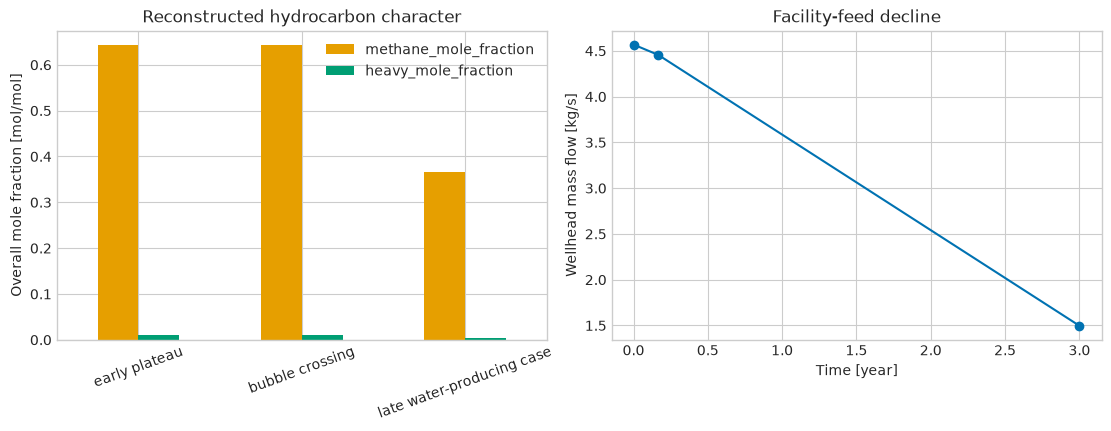

In [24]:
composition_figure, composition_axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.2),
    constrained_layout=True,
)

composition_figure_data = characterized_snapshot_table.set_index("case")
composition_figure_data[
    ["methane_mole_fraction", "heavy_mole_fraction"]
].plot.bar(
    ax=composition_axes[0],
    color=["#E69F00", "#009E73"],
)
composition_axes[0].set_ylabel("Overall mole fraction [mol/mol]")
composition_axes[0].set_xlabel("")
composition_axes[0].set_title("Reconstructed hydrocarbon character")
composition_axes[0].tick_params(axis="x", rotation=20)

composition_axes[1].plot(
    characterized_snapshot_table["time_year"],
    characterized_snapshot_table["mass_flow_kg_s"],
    marker="o",
    color="#0072B2",
)
composition_axes[1].set_xlabel("Time [year]")
composition_axes[1].set_ylabel("Wellhead mass flow [kg/s]")
composition_axes[1].set_title("Facility-feed decline")

composition_plot_path = (
    OUTPUT_DIRECTORY / "reconstructed_neqsim_flows.png"
)
composition_figure.savefig(composition_plot_path, dpi=150)
plt.show()

## 9. Feed a NeqSim surface-process model

The largest surface mass load in the Flow forecast is selected as a facility design case. The
reconstructed stream is flashed at 70 bara and 65°C, throttled to a 55 bara HP separator, and
split into gas, oil, and water. HP gas is compressed to 120 bara and cooled to 35°C. Oil is let
down to 10 bara and flashed again.

The flowsheet demonstrates a composable reservoir-to-process handoff. It does not size vessels,
chokes, piping, or the compressor.

In [25]:
reservoir_history["estimated_surface_mass_kg_s"] = (
    reservoir_history["oil_rate_Sm3_day"] * stock_oil_density_kg_m3
    + reservoir_history["gas_rate_Sm3_day"] * stock_gas_density_kg_m3
    + reservoir_history["water_rate_Sm3_day"]
    * stock_water_density_kg_m3
) / SECONDS_PER_DAY

facility_design_index = int(
    reservoir_history["estimated_surface_mass_kg_s"].idxmax()
)
facility_design_row = reservoir_history.iloc[facility_design_index]
facility_feed_fluid, facility_feed_audit = (
    reconstruct_characterized_wellhead_fluid(
        facility_design_row["oil_rate_Sm3_day"],
        facility_design_row["gas_rate_Sm3_day"],
        facility_design_row["water_rate_Sm3_day"],
    )
)

clearProcess()
reservoir_export_stream = stream(
    "OPM-derived characterized wellhead stream",
    facility_feed_fluid,
)
wellhead_choke = valve(
    "Wellhead choke",
    reservoir_export_stream,
    p=55.0,
)
hp_separator = separator3phase(
    "HP three-phase separator",
    wellhead_choke.getOutletStream(),
)
gas_compressor = compressor(
    "Export gas compressor",
    hp_separator.getGasOutStream(),
    pres=120.0,
)
gas_compressor.setIsentropicEfficiency(0.75)
gas_aftercooler = cooler(
    "Export gas aftercooler",
    gas_compressor.getOutletStream(),
)
gas_aftercooler.setOutTemperature(35.0 + 273.15)
oil_valve = valve(
    "Oil letdown valve",
    hp_separator.getOilOutStream(),
    p=10.0,
)
lp_separator = separator(
    "LP oil separator",
    oil_valve.getOutletStream(),
)
runProcess()

In [26]:
process_streams = [
    reservoir_export_stream,
    wellhead_choke.getOutletStream(),
    hp_separator.getGasOutStream(),
    hp_separator.getOilOutStream(),
    hp_separator.getWaterOutStream(),
    gas_aftercooler.getOutletStream(),
    lp_separator.getGasOutStream(),
    lp_separator.getLiquidOutStream(),
]

process_stream_table = pd.DataFrame(
    [
        {
            "stream": str(process_stream.getName()),
            "mass_flow_kg_s": process_stream.getFlowRate("kg/sec"),
            "temperature_C": process_stream.getTemperature("C"),
            "pressure_bara": process_stream.getPressure("bara"),
            "phase_count": (
                process_stream.getFluid().getNumberOfPhases()
            ),
        }
        for process_stream in process_streams
    ]
)

process_outlet_streams = [
    gas_aftercooler.getOutletStream(),
    lp_separator.getGasOutStream(),
    lp_separator.getLiquidOutStream(),
    hp_separator.getWaterOutStream(),
]
process_outlet_mass_flow_kg_s = sum(
    process_stream.getFlowRate("kg/sec")
    for process_stream in process_outlet_streams
)
process_mass_residual_kg_s = (
    reservoir_export_stream.getFlowRate("kg/sec")
    - process_outlet_mass_flow_kg_s
)

process_performance = pd.DataFrame(
    {
        "quantity": [
            "Flow forecast time",
            "Flow oil rate",
            "Flow gas rate",
            "Flow water rate",
            "NeqSim feed mass rate",
            "process mass residual",
            "compressor power",
            "aftercooler duty",
        ],
        "value": [
            facility_design_row["time_days"] / 365.25,
            facility_design_row["oil_rate_Sm3_day"],
            facility_design_row["gas_rate_Sm3_day"],
            facility_design_row["water_rate_Sm3_day"],
            reservoir_export_stream.getFlowRate("kg/sec"),
            process_mass_residual_kg_s,
            gas_compressor.getPower() / 1.0e6,
            gas_aftercooler.getDuty() / 1.0e6,
        ],
        "unit": [
            "year",
            "Sm³/day",
            "Sm³/day",
            "Sm³/day",
            "kg/s",
            "kg/s",
            "MW",
            "MW",
        ],
    }
)

display(process_stream_table)
display(process_performance)

,stream,mass_flow_kg_s,temperature_C,pressure_bara,phase_count
0,OPM-derived characterized wellhead stream,7.731016e+00,65.000000,70.0,2
1,Wellhead choke out stream,7.731016e+00,58.820023,55.0,2
2,gasOutStream,6.743376e+00,58.820023,55.0,1
3,liquidOutStream,9.876397e-01,58.820023,55.0,1
4,waterOutStream,1.430288e-29,58.820023,55.0,2
5,outStream,6.743376e+00,35.000000,120.0,1
6,gasOutStream,1.917310e-01,37.001767,10.0,1
7,liquidOutStream,7.959087e-01,37.001767,10.0,1


,quantity,value,unit
0,Flow forecast time,7.500000e-01,year
1,Flow oil rate,1.500000e+03,Sm³/day
2,Flow gas rate,5.816937e+05,Sm³/day
3,Flow water rate,4.282055e-02,Sm³/day
4,NeqSim feed mass rate,7.731016e+00,kg/s
5,process mass residual,4.415135e-12,kg/s
6,compressor power,6.959609e-01,MW
7,aftercooler duty,-1.926287e+00,MW


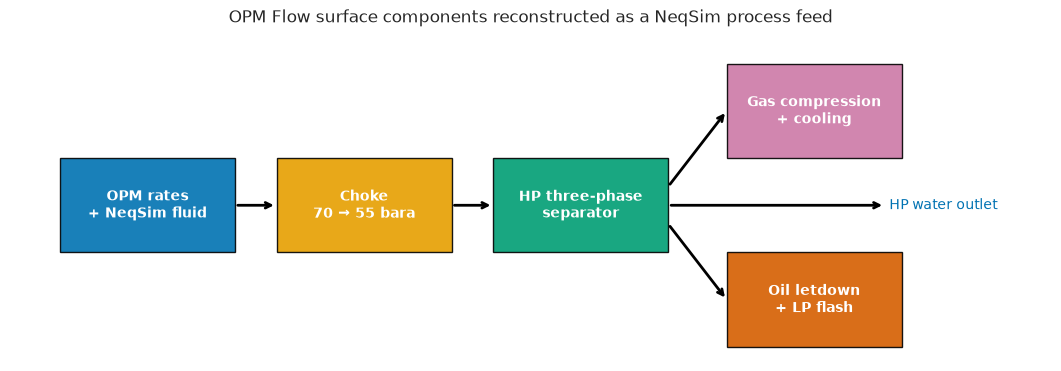

In [27]:
process_figure, process_axis = plt.subplots(figsize=(10.5, 3.6), constrained_layout=True)
process_axis.set_xlim(0.0, 12.5)
process_axis.set_ylim(0.0, 3.5)
process_axis.axis("off")

process_nodes = [
    (0.6, 1.15, "OPM rates\n+ NeqSim fluid", "#0072B2"),
    (3.2, 1.15, "Choke\n70 → 55 bara", "#E69F00"),
    (5.8, 1.15, "HP three-phase\nseparator", "#009E73"),
    (8.6, 2.15, "Gas compression\n+ cooling", "#CC79A7"),
    (8.6, 0.15, "Oil letdown\n+ LP flash", "#D55E00"),
]

for x_position, y_position, label, color in process_nodes:
    process_axis.add_patch(
        plt.Rectangle(
            (x_position, y_position),
            2.1,
            1.0,
            facecolor=color,
            edgecolor="black",
            alpha=0.9,
        )
    )
    process_axis.text(
        x_position + 1.05,
        y_position + 0.5,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

arrow_pairs = [
    ((2.7, 1.65), (3.2, 1.65)),
    ((5.3, 1.65), (5.8, 1.65)),
    ((7.9, 1.85), (8.6, 2.65)),
    ((7.9, 1.45), (8.6, 0.65)),
    ((7.9, 1.65), (10.5, 1.65)),
]
for arrow_start, arrow_end in arrow_pairs:
    process_axis.annotate(
        "",
        xy=arrow_end,
        xytext=arrow_start,
        arrowprops={"arrowstyle": "->", "linewidth": 2.0},
    )

process_axis.text(
    11.2,
    1.65,
    "HP water outlet",
    ha="center",
    va="center",
    color="#0072B2",
)
process_axis.set_title(
    "OPM Flow surface components reconstructed as a NeqSim process feed"
)

process_plot_path = OUTPUT_DIRECTORY / "integrated_process_workflow.png"
process_figure.savefig(process_plot_path, dpi=150)
plt.show()

## 10. Executable engineering validation

The checks cover source composition, black-oil monotonicity, OPM parsing and execution, finite
summary and restart arrays, grid dimensions, cell-saturation closure, expected depletion
behavior, water breakthrough, reverse-conversion mass closure, component retention, process
pressure ordering, and total process mass balance.

The evidence level is cross-software execution plus conservation and thermodynamic consistency.
It is not a comparison with field data.

In [28]:
all_numeric_history = reservoir_history.select_dtypes(
    include=[np.number]
).to_numpy()
maximum_snapshot_mass_residual_kg_s = (
    characterized_snapshot_table["mass_residual_kg_s"].abs().max()
)

validation_checks = {
    "input assay closes to 100 mol%": abs(
        fluid_audit.loc[
            fluid_audit["quantity"] == "input assay closure",
            "value",
        ].iloc[0]
        - 100.0
    )
    < 1.0e-10,
    "characterized composition closes": (
        abs(composition_sum - 1.0) < 1.0e-12
    ),
    "22 characterized hydrocarbon components": (
        reservoir_fluid.getNumberOfComponents() == 22
    ),
    "initial state is single-phase oil": (
        initial_state.getNumberOfPhases() == 1
        and initial_state.hasPhaseType("oil")
    ),
    "bubble-pressure methods agree": abs(
        bubble_pressure_bara - bubble_pressure_reference_bara
    )
    < 0.1,
    "all PVT contracts pass": bool(
        pvt_contract_audit["passed"].all()
    ),
    "all required deck keywords parse": bool(
        deck_keyword_audit["present"].all()
    ),
    "OPM Flow returned success": flow_run.returncode == 0,
    "OPM summary contains finite values": np.isfinite(
        all_numeric_history
    ).all(),
    "grid geometry matches the deck": (
        (grid_nx, grid_ny, grid_nz) == (10, 10, 3)
        and active_cell_count == 300
    ),
    "restart spans the complete 36-step schedule": (
        restart_steps
        in [list(range(37)), list(range(1, 37))]
    ),
    "restart cell states are finite": np.isfinite(
        np.concatenate(
            [
                final_pressure_cube_bara.ravel(),
                final_water_saturation_cube.ravel(),
                final_gas_saturation_cube.ravel(),
            ]
        )
    ).all(),
    "final cell saturations close": (
        final_oil_saturation_cube.min() >= -1.0e-6
        and (
            final_water_saturation_cube
            + final_gas_saturation_cube
        ).max()
        <= 1.0 + 1.0e-6
    ),
    "reservoir pressure declines": (
        reservoir_history["field_pressure_bara"].iloc[-1]
        < reservoir_history["field_pressure_bara"].iloc[0]
    ),
    "bubble pressure is crossed": bubble_crossing_index is not None,
    "producer reaches BHP constraint": bhp_limited_index is not None,
    "water breakthrough occurs": water_breakthrough_index is not None,
    "oil and gas rates remain non-negative": (
        reservoir_history[
            ["oil_rate_Sm3_day", "gas_rate_Sm3_day"]
        ].to_numpy()
        >= 0.0
    ).all(),
    "reverse conversion retains 23 components": (
        characterized_snapshot_table["component_count"] == 23
    ).all(),
    "reverse conversion mass closes": (
        maximum_snapshot_mass_residual_kg_s < 1.0e-10
    ),
    "late case is water-bearing": (
        characterized_snapshot_table.iloc[-1][
            "water_mole_fraction"
        ]
        > characterized_snapshot_table.iloc[0][
            "water_mole_fraction"
        ]
    ),
    "compressor raises pressure": (
        gas_aftercooler.getOutletStream().getPressure("bara")
        > hp_separator.getGasOutStream().getPressure("bara")
    ),
    "compressor consumes positive power": (
        gas_compressor.getPower() > 0.0
    ),
    "aftercooler removes heat": gas_aftercooler.getDuty() < 0.0,
    "integrated process mass closes": (
        abs(process_mass_residual_kg_s) < 1.0e-10
    ),
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)

failed_checks = validation_table.loc[
    ~validation_table["passed"],
    "check",
].tolist()
if failed_checks:
    raise AssertionError(f"Failed validation checks: {failed_checks}")

print(f"All {len(validation_checks)} engineering checks passed.")

All 25 engineering checks passed.


,check,passed
0,input assay closes to 100 mol%,True
1,characterized composition closes,True
2,22 characterized hydrocarbon components,True
3,initial state is single-phase oil,True
4,bubble-pressure methods agree,True
5,all PVT contracts pass,True
6,all required deck keywords parse,True
7,OPM Flow returned success,True
8,OPM summary contains finite values,True
9,grid geometry matches the deck,True


In [29]:
final_results = {
    "neqsim_version": version("neqsim"),
    "opm_flow_version": flow_version_match.group(1),
    "eos": "SRK",
    "mixing_rule": "classic",
    "characterized_hydrocarbon_components": int(
        reservoir_fluid.getNumberOfComponents()
    ),
    "active_grid_cells": active_cell_count,
    "restart_report_steps": len(restart_steps),
    "bubble_pressure_bara": bubble_pressure_bara,
    "initial_solution_gor_Sm3_Sm3": initial_rs_sm3_sm3,
    "final_field_pressure_bara": float(
        reservoir_history["field_pressure_bara"].iloc[-1]
    ),
    "peak_gas_rate_Sm3_day": float(
        reservoir_history["gas_rate_Sm3_day"].max()
    ),
    "final_water_rate_Sm3_day": float(
        reservoir_history["water_rate_Sm3_day"].iloc[-1]
    ),
    "maximum_final_water_saturation": float(
        final_water_saturation_cube.max()
    ),
    "maximum_final_gas_saturation": float(
        final_gas_saturation_cube.max()
    ),
    "facility_feed_mass_kg_s": float(
        reservoir_export_stream.getFlowRate("kg/sec")
    ),
    "compressor_power_MW": float(
        gas_compressor.getPower() / 1.0e6
    ),
    "aftercooler_duty_MW": float(
        gas_aftercooler.getDuty() / 1.0e6
    ),
    "process_mass_residual_kg_s": float(
        process_mass_residual_kg_s
    ),
    "validation_checks_passed": int(
        validation_table["passed"].sum()
    ),
    "validation_checks_total": int(len(validation_table)),
}

final_summary = pd.DataFrame(
    {
        "quantity": [
            "bubble pressure",
            "initial solution GOR",
            "final field pressure",
            "peak gas rate",
            "final water rate",
            "facility feed",
            "compressor power",
            "aftercooler duty",
        ],
        "value": [
            final_results["bubble_pressure_bara"],
            final_results["initial_solution_gor_Sm3_Sm3"],
            final_results["final_field_pressure_bara"],
            final_results["peak_gas_rate_Sm3_day"],
            final_results["final_water_rate_Sm3_day"],
            final_results["facility_feed_mass_kg_s"],
            final_results["compressor_power_MW"],
            final_results["aftercooler_duty_MW"],
        ],
        "unit": [
            "bara",
            "Sm³/Sm³",
            "bara",
            "Sm³/day",
            "Sm³/day",
            "kg/s",
            "MW",
            "MW",
        ],
    }
)

display(final_summary)
results_path = OUTPUT_DIRECTORY / "coupled_run_results.json"
results_path.write_text(
    json.dumps(final_results, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
print(json.dumps(final_results, indent=2, sort_keys=True))
print(f"Run manifest: {results_path}")

{
  "active_grid_cells": 300,
  "aftercooler_duty_MW": -1.9262871969495952,
  "bubble_pressure_bara": 193.24040031433105,
  "characterized_hydrocarbon_components": 22,
  "compressor_power_MW": 0.6959608988373328,
  "eos": "SRK",
  "facility_feed_mass_kg_s": 7.731015510081117,
  "final_field_pressure_bara": 89.48109436035156,
  "final_water_rate_Sm3_day": 44.18187713623047,
  "initial_solution_gor_Sm3_Sm3": 224.67271008582603,
  "maximum_final_gas_saturation": 0.6170697808265686,
  "maximum_final_water_saturation": 0.813498854637146,
  "mixing_rule": "classic",
  "neqsim_version": "3.23.0",
  "opm_flow_version": "2026.04",
  "peak_gas_rate_Sm3_day": 581693.6875,
  "process_mass_residual_kg_s": 4.4151349243293225e-12,
  "restart_report_steps": 37,
  "validation_checks_passed": 25,
  "validation_checks_total": 25
}
Run manifest: phase_evolution_opm_outputs/coupled_run_results.json


,quantity,value,unit
0,bubble pressure,193.240400,bara
1,initial solution GOR,224.672710,Sm³/Sm³
2,final field pressure,89.481094,bara
3,peak gas rate,581693.687500,Sm³/day
4,final water rate,44.181877,Sm³/day
5,facility feed,7.731016,kg/s
6,compressor power,0.695961,MW
7,aftercooler duty,-1.926287,MW


## Engineering interpretation

- The reservoir begins above bubble pressure and initially produces the solution GOR generated by
  NeqSim.
- After pressure crosses the bubble point, mobile gas develops, GOR rises, and gas handling
  becomes a time-dependent facility constraint.
- The water injector delays local depletion but eventually causes a produced-water case.
- The reverse conversion preserves 22 characterized hydrocarbon identities and adds water as the
  23rd component; it therefore supports phase equilibrium and equipment calculations that the
  black-oil model cannot perform itself.
- The maximum surface mass-load case, not the last reservoir step, is used for the demonstration
  compressor and cooler duty.

## Applicability and remaining limitations

The notebook is suitable for teaching, open workflow development, early facility-feed generation,
and testing data contracts between reservoir and process simulators.

Important limitations:

- The black-oil reduction loses detailed compositional evolution inside the reservoir.
- Stock-oil and surface-gas component compositions are held fixed during reverse conversion.
- PVT data are synthetic and not regressed to CCE, DLE, separator, viscosity, or swelling data.
- The grid has no faults, local refinement, aquifer, hysteresis, geomechanics, thermal effects,
  salinity, history match, or wellbore hydraulics.
- Facility pressure does not feed back into the Flow well constraint in this one-way workflow.
- Equipment results are thermodynamic screening values, not mechanical design or code compliance.

A production workflow should automate PVT regression, export provenance, summary schema checks,
well-to-facility iteration, uncertainty cases, and version-controlled run manifests.

## Validation scope

The saved outputs below were produced from the pinned NeqSim source and the OPM version
reported in setup. Executable checks cover laboratory mole accounting, phase-boundary bracketing,
PVT table contracts, deck parsing, reservoir results, handoff mass closure, and process behavior.
These are consistency and physical-bounds checks, not experimental validation.

The notebook uses an existing teaching approximation: viscosities are flashed from the original
assay rather than stage-specific DLE residual compositions, and dry-gas composition is fixed.
A field-quality black-oil reduction needs matched separator tests and residual-oil viscosities.


Execution: 29 code cells in a fresh IPython process; 25 integrated checks plus the
PVT assertions passed. NeqSim source is pinned to the commit reported in setup.
OPM Flow 2026.04 was used. The setup supports an existing Flow installation or an
Ubuntu Colab installation; the Colab package-install branch was not exercised locally.


## References and suggested exercises

**Primary software references**

- [OPM Flow project and installation](https://opm-project.org/?page_id=36)
- [OPM Flow 2026.04 release announcement](https://opm-project.org/?page_id=287)
- [OPM simulators source](https://github.com/OPM/opm-simulators)
- [OPM public SPE1 test deck](https://github.com/OPM/opm-tests/tree/master/spe1)
- [NeqSim PVT workflow](https://equinor.github.io/neqsim/pvtsimulation/pvt_workflow.html)
- [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)

**Exercises**

1. Change the number of heavy-end pseudo-components and quantify PVT and process-duty sensitivity.
2. Replace the synthetic assay with a public PVT dataset and regress bubble pressure, density,
   viscosity, CCE, and DLE data.
3. Move the injector and compare water breakthrough and facility water handling.
4. Add a tubing or pipeline model and iterate the NeqSim arrival pressure with Flow's BHP control.
5. Export several Flow dates as a time series of NeqSim process cases and identify bottlenecks.
6. Compare this black-oil workflow with an OPM compositional case when a stable public interface is
   available.

## Research next steps for issue #4198

1. Obtain the paper and its supporting assays, temperatures, pressures, and phase observations.
2. Regress EOS characterization against measured saturation pressure, CME, and CVD data;
   reserve independent measurements for validation and quantify heavy-end uncertainty.
3. Add geological charge and migration paths, rock functions, capillary pressure, and boundary
   conditions. A series of equilibrium flashes alone is not a migration simulation.
4. Compare compositional transport with the black-oil approximation, particularly near critical
   conditions and where migrating gas changes composition.
5. Propagate the resulting production envelope into NeqSim separation, compression, and
   flow-assurance calculations using explicit transfer contracts.

This demonstration addresses the software workflow proposed by #4198; it does not close the
research issue. Change the temperature sensitivity or pressure schedule, rerun, and explain
which conclusions depend on laboratory path and which depend on spatial transport.
